In [12]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, sosfreqz, sosfiltfilt
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis, skew
from tqdm import tqdm

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## 2. Parámetros generales


In [111]:
from pathlib import Path

BASE_DIR = Path.cwd().resolve()

while BASE_DIR.name != "Verde_Oscuro_RETO11" and BASE_DIR.parent != BASE_DIR:
    BASE_DIR = BASE_DIR.parent

base_path = (
    BASE_DIR
    / "Datos"
    / "Transformados"
    / "Industria"
    / "bearing_fault_detection_processed"
)

print(" base_path:", base_path.resolve())
print("Existe:", base_path.exists())

 base_path: C:\Bdata3\Verde_Oscuro_RETO11\Datos\Transformados\Industria\bearing_fault_detection_processed
Existe: True


## 3. Carga de datos



In [106]:
def infer_metadata_from_path(csv_path: Path, base_path: Path):
    """
    Extrae metadatos a partir de la ruta relativa del archivo CSV.
    Soporta estructuras con distinta profundidad.
    """
    rel_parts = csv_path.relative_to(base_path).parts[:-1]  
    filename = csv_path.name

    mount_position = "none"
    label = "unknown"
    fault_level = "none"

    if len(rel_parts) == 1:
        label = rel_parts[0]

    elif len(rel_parts) == 2:
        label = rel_parts[0]
        fault_level = rel_parts[1]

    elif len(rel_parts) >= 3:
        mount_position = rel_parts[0]
        label = rel_parts[1]
        fault_level = rel_parts[2]

    return {
        "mount_position": mount_position,
        "label": label,
        "fault_level": fault_level,
        "source_file": str(Path(*rel_parts) / filename)
    }


def load_dataset_recursive(base_path: Path) -> pd.DataFrame:
    data = []

    csv_files = list(base_path.rglob("*.csv"))
    if not csv_files:
        raise ValueError("No se han encontrado CSV en la ruta indicada.")

    for csv_path in tqdm(csv_files, desc="Cargando CSVs"):
        try:
            df = pd.read_csv(csv_path)
            meta = infer_metadata_from_path(csv_path, base_path)

            for key, value in meta.items():
                df[key] = value

            data.append(df)

        except Exception as e:
            print(f"Error leyendo {csv_path}: {e}")

    if not data:
        raise ValueError("No se ha podido cargar ningún archivo CSV válido.")

    return pd.concat(data, ignore_index=True)

In [107]:
df_all = load_dataset_recursive(base_path)
print("Shape total:", df_all.shape)

df_all.head()

Cargando CSVs: 100%|██████████| 168/168 [00:26<00:00,  6.39it/s]


Shape total: (41962500, 12)


,tachometer,acc_under_axial,acc_under_radiale,acc_under_tangencial,acc_over_axial,acc_over_radiale,acc_over_tangencial,microphone,mount_position,label,fault_level,source_file
0,-0.49977,0.97159,0.086419,-0.017590,0.64014,0.19493,0.35288,0.021614,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
1,-0.54833,-1.21600,-0.353530,-0.060630,0.50864,0.19588,0.23587,0.045124,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
2,-0.44806,1.33940,0.285630,0.064970,0.65422,0.19641,0.37791,-0.070311,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
3,-0.57483,-1.25120,-0.474590,0.016734,0.47286,0.19298,0.21212,0.124980,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
4,-0.45559,0.84107,0.314980,0.124230,0.62664,0.19460,0.36869,-0.133050,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv


In [104]:
df_all[:20000000]

,tachometer,acc_under_axial,acc_under_radiale,acc_under_tangencial,acc_over_axial,acc_over_radiale,acc_over_tangencial,microphone,mount_position,label,fault_level,source_file
0,-0.49977,0.971590,0.086419,-0.017590,0.64014,0.194930,0.35288,0.021614,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
1,-0.54833,-1.216000,-0.353530,-0.060630,0.50864,0.195880,0.23587,0.045124,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
2,-0.44806,1.339400,0.285630,0.064970,0.65422,0.196410,0.37791,-0.070311,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
3,-0.57483,-1.251200,-0.474590,0.016734,0.47286,0.192980,0.21212,0.124980,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
4,-0.45559,0.841070,0.314980,0.124230,0.62664,0.194600,0.36869,-0.133050,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
...,...,...,...,...,...,...,...,...,...,...,...,...
19999995,4.53960,1.131500,0.108200,0.018532,1.19220,0.030052,0.31522,0.015383,overhang,outer_race,0g,overhang\outer_race\0g\13.1072.csv
19999996,4.52070,0.031915,0.137420,-0.017571,1.17820,0.032504,0.30306,-0.053761,overhang,outer_race,0g,overhang\outer_race\0g\13.1072.csv
19999997,4.52610,1.691200,0.211410,-0.020570,1.19250,0.031971,0.32158,-0.031954,overhang,outer_race,0g,overhang\outer_race\0g\13.1072.csv
19999998,4.53280,0.004705,0.092553,-0.009382,1.16640,0.031381,0.30831,-0.033512,overhang,outer_race,0g,overhang\outer_race\0g\13.1072.csv


Agrega bien hasta las carpetas con mayores subcarpetas (overhang y underhang)

## 4.1. Revisión inicial del dataset
Comprobamos tipos, columnas, clases presentes y número de archivos por clase.

In [17]:
print("Columnas:")
print(df_all.columns.tolist())
print("\nTipos:")
print(df_all.dtypes)


Columnas:
['tachometer', 'acc_under_axial', 'acc_under_radiale', 'acc_under_tangencial', 'acc_over_axial', 'acc_over_radiale', 'acc_over_tangencial', 'microphone', 'mount_position', 'label', 'fault_level', 'source_file']

Tipos:
tachometer              float64
acc_under_axial         float64
acc_under_radiale       float64
acc_under_tangencial    float64
acc_over_axial          float64
acc_over_radiale        float64
acc_over_tangencial     float64
microphone              float64
mount_position              str
label                       str
fault_level                 str
source_file                 str
dtype: object


En formato float64, cada numerito ocupa 8 bytes de RAM. Cambiar a float32

Los formatos object (texto puro) consumen muchísima memoria en Pandas. Cambiar a category

In [18]:
print("Distribución por clase:")
print(df_all["label"].value_counts())

print("\nNúmero de archivos por clase:")
print(df_all.groupby("label")["source_file"].nunique().sort_values(ascending=False))

Distribución por clase:
label
ball_fault                 8000000
cage_fault                 8000000
outer_race                 8000000
imbalance                  7000000
vertical-misalignment      6000000
horizontal-misalignment    3962500
normal                     1000000
Name: count, dtype: int64

Número de archivos por clase:
label
ball_fault                 32
cage_fault                 32
outer_race                 32
imbalance                  28
vertical-misalignment      24
horizontal-misalignment    16
normal                      4
Name: source_file, dtype: int64


In [19]:
print("Distribución por posición de montaje:")
print(df_all["mount_position"].value_counts(dropna=False))

Distribución por posición de montaje:
mount_position
none         17962500
overhang     12000000
underhang    12000000
Name: count, dtype: int64


In [20]:
print("Distribución por nivel de fallo:")
print(df_all["fault_level"].value_counts(dropna=False))

Distribución por nivel de fallo:
fault_level
20g       7000000
35g       7000000
6g        7000000
0g        6000000
0.5mm     1000000
1.5mm     1000000
2.0mm     1000000
10g       1000000
15g       1000000
25g       1000000
30g       1000000
none      1000000
0.51mm    1000000
0.63mm    1000000
1.27mm    1000000
1.40mm    1000000
1.78mm    1000000
1.90mm    1000000
1.0mm      962500
Name: count, dtype: int64


## 4.2. Limpieza básica y optimización de memoria



In [21]:
for col in signal_cols:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce").astype("float32")

df_all["mount_position"] = df_all["mount_position"].astype("category")
df_all["label"] = df_all["label"].astype("category")
df_all["fault_level"] = df_all["fault_level"].astype("category")
df_all["source_file"] = df_all["source_file"].astype("category")

In [22]:
print("NaN por columna:")
missing = df_all.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

print("\nDuplicados:", df_all.duplicated().sum())

NaN por columna:
Series([], dtype: int64)

Duplicados: 0


In [23]:
df_all['mount_position'].unique()

['none', 'overhang', 'underhang']
Categories (3, str): ['none', 'overhang', 'underhang']

In [24]:
df_all = df_all.drop_duplicates().copy()

for col in signal_cols:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce").astype("float32")

df_all["mount_position"] = df_all["mount_position"].astype("category")
df_all["label"] = df_all["label"].astype("category")
df_all["fault_level"] = df_all["fault_level"].astype("category")
df_all["source_file"] = df_all["source_file"].astype("category")

df_all = df_all.dropna(subset=signal_cols).copy()

print("Shape tras limpieza:", df_all.shape)
print(df_all.dtypes.head(20))

Shape tras limpieza: (41962500, 12)
tachometer               float64
acc_under_axial          float32
acc_under_radiale        float32
acc_under_tangencial     float32
acc_over_axial           float64
acc_over_radiale         float64
acc_over_tangencial      float64
microphone               float64
mount_position          category
label                   category
fault_level             category
source_file             category
dtype: object


## 5. Exploración rápida

Se muestra:
- distribución de clases,
- una señal de ejemplo,
- histograma de una señal.

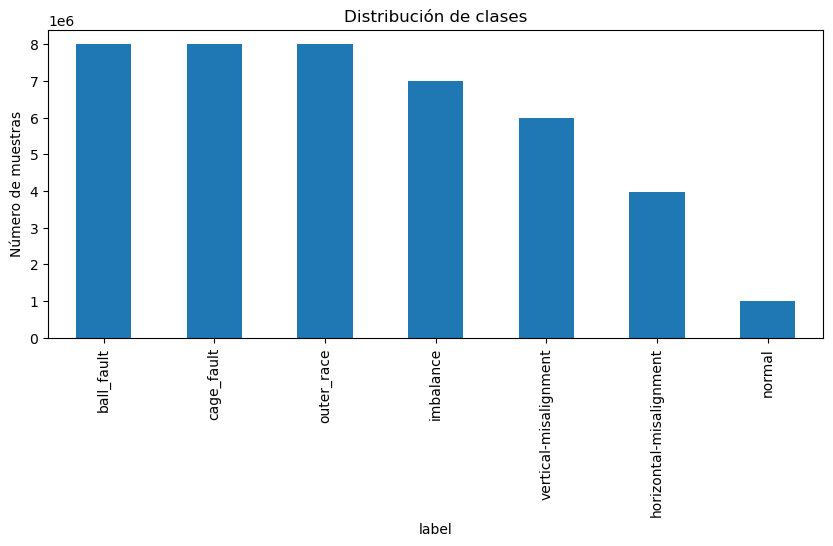

In [25]:
df_all["label"].value_counts().plot(kind="bar", figsize=(10, 4), title="Distribución de clases")
plt.ylabel("Número de muestras")
plt.show()

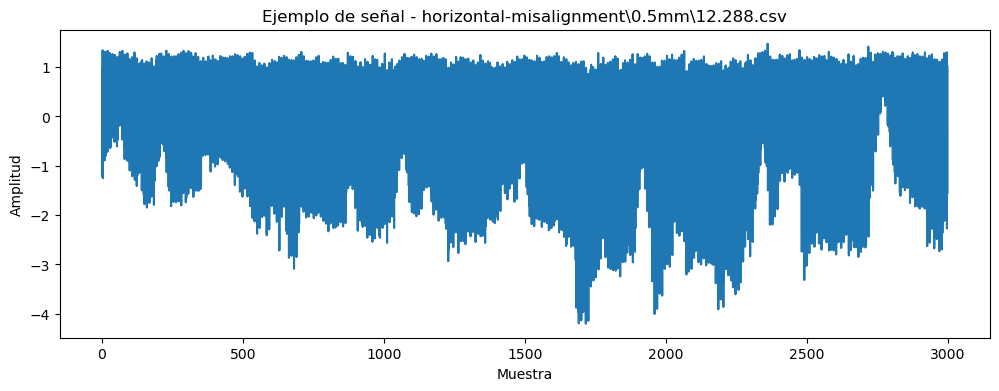

In [26]:
archivo_demo = df_all["source_file"].iloc[0]
demo = df_all[df_all["source_file"] == archivo_demo].reset_index(drop=True)

plt.figure(figsize=(12, 4))
plt.plot(demo["acc_under_axial"].values[:3000])
plt.title(f"Ejemplo de señal - {archivo_demo}")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.show()

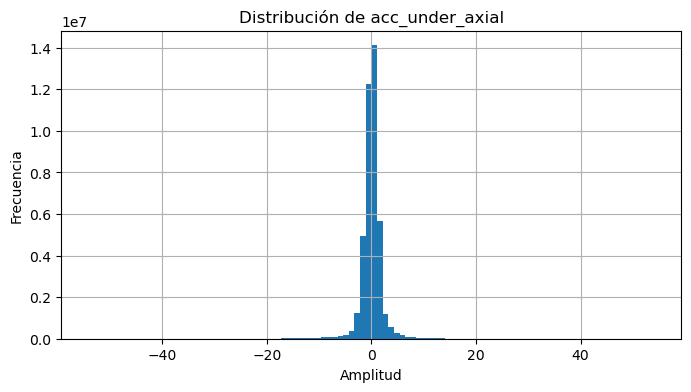

In [27]:
plt.figure(figsize=(8, 4))
df_all["acc_under_axial"].hist(bins=100)
plt.title("Distribución de acc_under_axial")
plt.xlabel("Amplitud")
plt.ylabel("Frecuencia")
plt.show()

## 6. Revisión de outliers

En señales de vibración, los valores extremos no siempre son errores; pueden ser impactos o eventos mecánicos relevantes.
Por ello, en este notebook no se eliminan automáticamente.

In [28]:
col = "acc_under_axial"
z_scores = np.abs((df_all[col] - df_all[col].mean()) / df_all[col].std())
outliers = df_all[z_scores > 3]

print("Outliers detectados en", col, ":", len(outliers))
print("Porcentaje:", round(len(outliers) / len(df_all) * 100, 3), "%")

Outliers detectados en acc_under_axial : 730403
Porcentaje: 1.741 %


In [29]:
df_all

,tachometer,acc_under_axial,acc_under_radiale,acc_under_tangencial,acc_over_axial,acc_over_radiale,acc_over_tangencial,microphone,mount_position,label,fault_level,source_file
0,-0.49977,0.97159,0.086419,-0.017590,0.64014,0.194930,0.352880,0.021614,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
1,-0.54833,-1.21600,-0.353530,-0.060630,0.50864,0.195880,0.235870,0.045124,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
2,-0.44806,1.33940,0.285630,0.064970,0.65422,0.196410,0.377910,-0.070311,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
3,-0.57483,-1.25120,-0.474590,0.016734,0.47286,0.192980,0.212120,0.124980,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
4,-0.45559,0.84107,0.314980,0.124230,0.62664,0.194600,0.368690,-0.133050,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv
...,...,...,...,...,...,...,...,...,...,...,...,...
41962495,4.36970,-0.97818,0.178700,-0.081023,0.11404,0.042316,0.313530,0.246470,none,vertical-misalignment,1.90mm,vertical-misalignment\1.90mm\61.0304.csv
41962496,4.36130,-0.71186,0.054562,1.608100,0.13895,0.042733,-0.069182,0.006865,none,vertical-misalignment,1.90mm,vertical-misalignment\1.90mm\61.0304.csv
41962497,4.36920,-0.96899,0.053341,2.842900,0.16757,0.048945,-0.447510,0.011197,none,vertical-misalignment,1.90mm,vertical-misalignment\1.90mm\61.0304.csv
41962498,4.35910,-0.30503,-0.330250,3.265300,0.17166,0.049022,-0.879930,0.151210,none,vertical-misalignment,1.90mm,vertical-misalignment\1.90mm\61.0304.csv


## 7. FFT para las diferentes señales

In [30]:
df_all['source_file'].unique()

['horizontal-misalignment\0.5mm\12.288.csv', 'horizontal-misalignment\0.5mm\30.3104.csv', 'horizontal-misalignment\0.5mm\50.176.csv', 'horizontal-misalignment\0.5mm\62.0544.csv', 'horizontal-misalignment\1.0mm\12.288.csv', ..., 'vertical-misalignment\1.78mm\62.0544.csv', 'vertical-misalignment\1.90mm\12.0832.csv', 'vertical-misalignment\1.90mm\30.3104.csv', 'vertical-misalignment\1.90mm\49.9712.csv', 'vertical-misalignment\1.90mm\61.0304.csv']
Length: 168
Categories (168, str): ['horizontal-misalignment\0.5mm\12.288.csv', 'horizontal-misalignment\0.5mm\30.3104.csv', 'horizontal-misalignment\0.5mm\50.176.csv', 'horizontal-misalignment\0.5mm\62.0544.csv', ..., 'vertical-misalignment\1.90mm\12.0832.csv', 'vertical-misalignment\1.90mm\30.3104.csv', 'vertical-misalignment\1.90mm\49.9712.csv', 'vertical-misalignment\1.90mm\61.0304.csv']

In [31]:
def extraer_velocidad(ruta):
    ruta_limpia = str(ruta).replace('\\', '/')
    archivo = ruta_limpia.split('/')[-1]
    numero = archivo.replace('.csv', '')
    return float(numero)

fs = 51200
n_fft = 4096

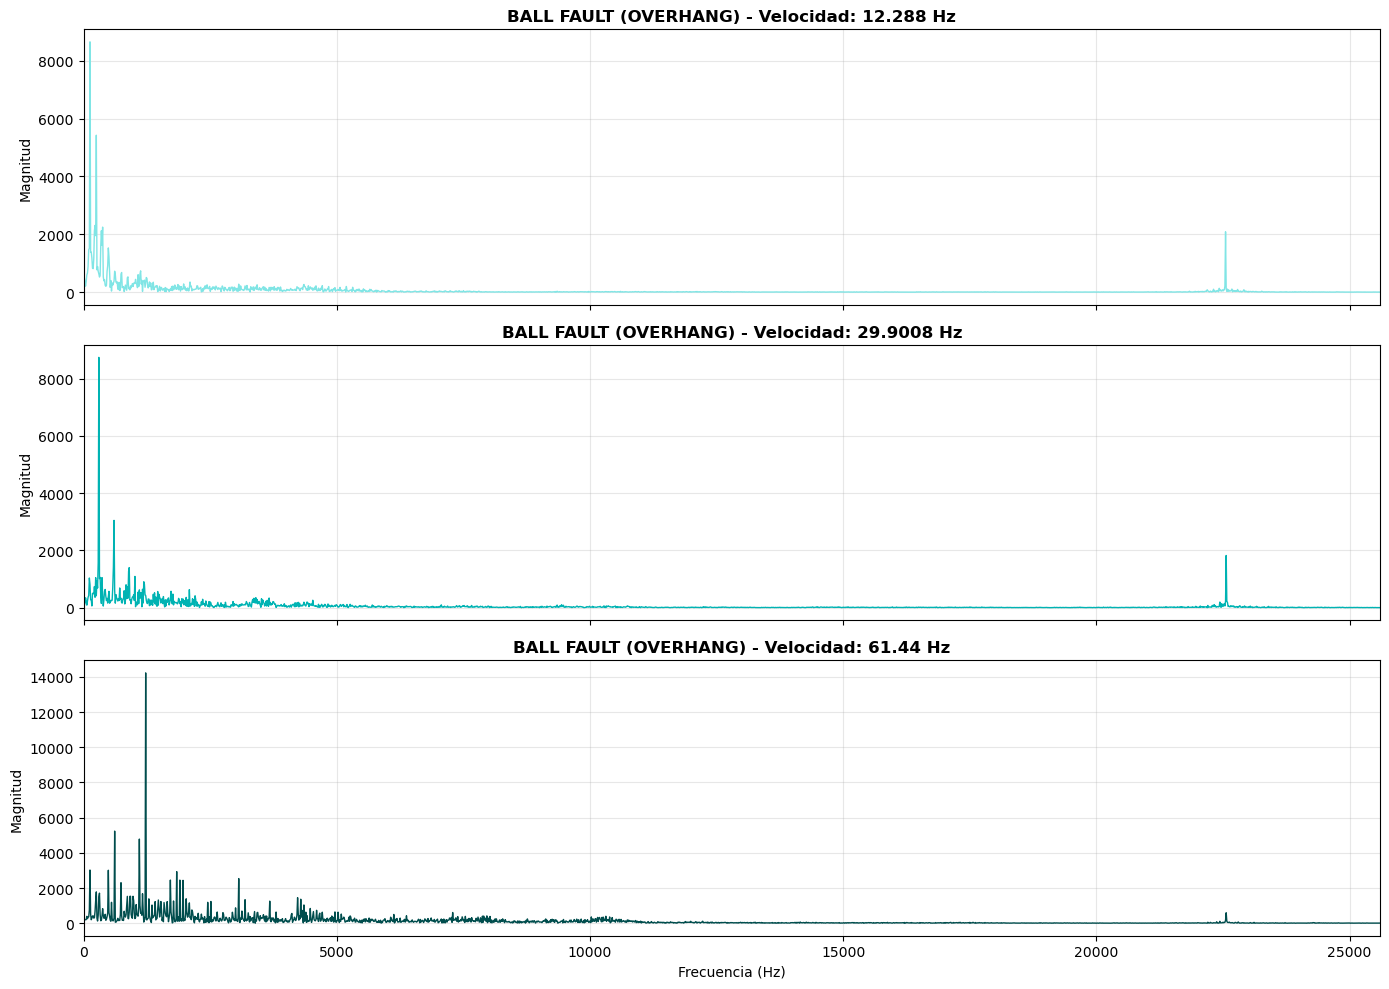

In [32]:
condicion_over = (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False))
df_ball_over = df_all[condicion_over]

archivos_ball_over = df_ball_over['source_file'].unique()

archivos_ordenados_over = sorted(archivos_ball_over, key=extraer_velocidad)
archivos_sel_over = [
    archivos_ordenados_over[0], 
    archivos_ordenados_over[len(archivos_ordenados_over)//2], 
    archivos_ordenados_over[-1]
]


colores_over = ["#80e5e5", "#00b3b3", "#004d4d"] # Paleta de turquesas

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, archivo in enumerate(archivos_sel_over):
    signal_cruda = df_ball_over[df_ball_over["source_file"] == archivo]["acc_under_axial"].values[:n_fft]
    
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0 
    
    axs[i].plot(rfreqs, rfft_mag, color=colores_over[i], linewidth=1)
    vel_hz = extraer_velocidad(archivo)
    axs[i].set_title(f"BALL FAULT (OVERHANG) - Velocidad: {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Magnitud")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[2].set_xlabel("Frecuencia (Hz)")
plt.tight_layout()
plt.show()

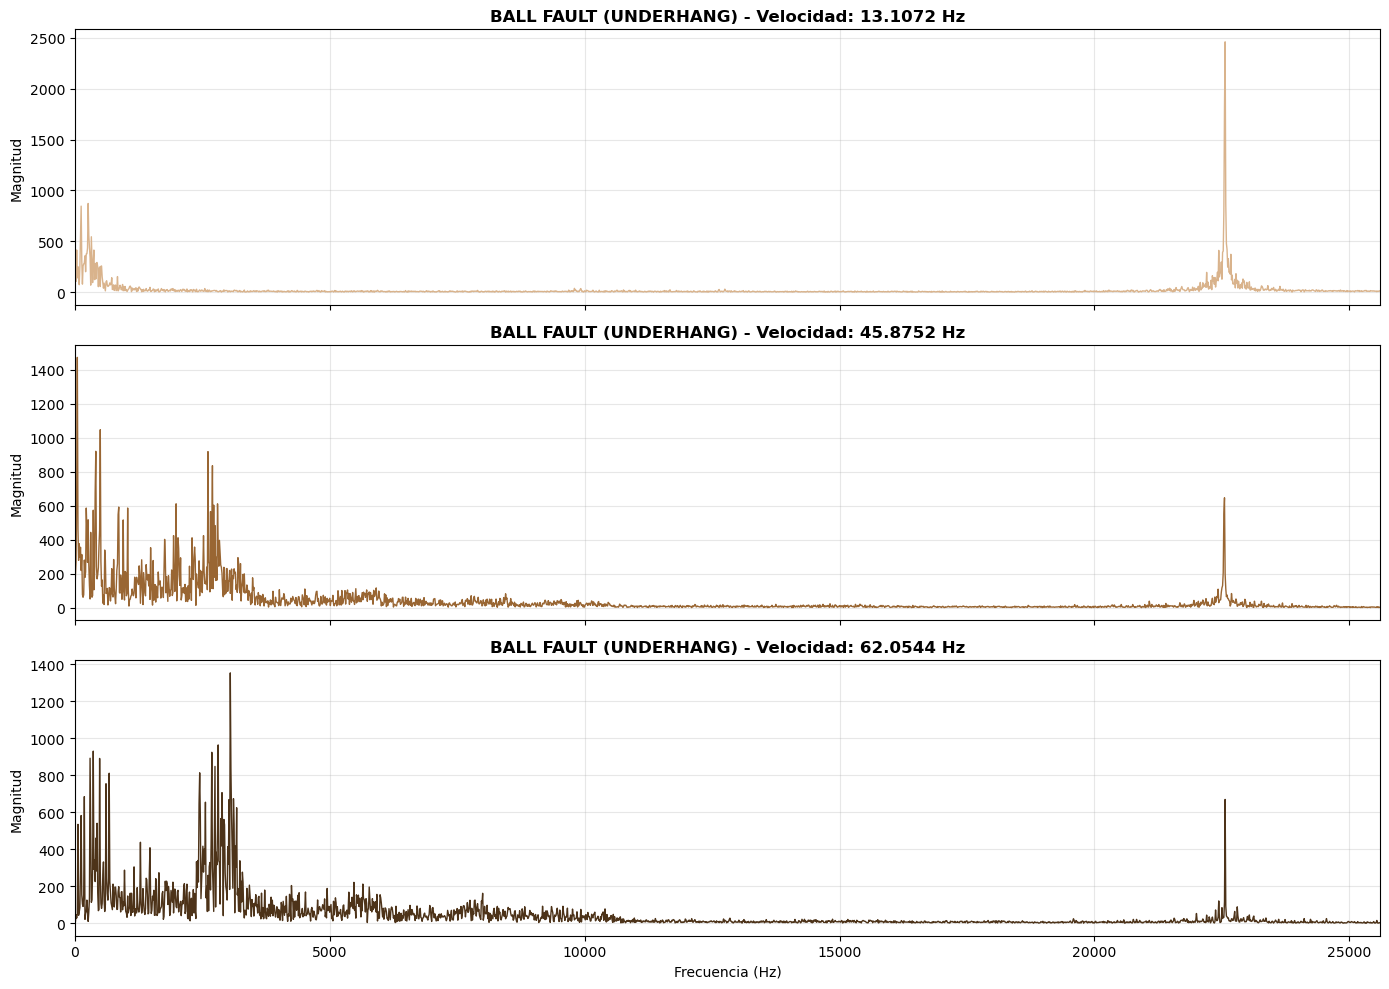

In [33]:
condicion_under = (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('underhang', case=False, na=False))
df_ball_under = df_all[condicion_under]

archivos_ball_under = df_ball_under['source_file'].unique()

archivos_ordenados_under = sorted(archivos_ball_under, key=extraer_velocidad)
archivos_sel_under = [
    archivos_ordenados_under[0], 
    archivos_ordenados_under[len(archivos_ordenados_under)//2], 
    archivos_ordenados_under[-1]
]

colores_under = ["#d9b38c", "#996633", "#4d3319"]

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, archivo in enumerate(archivos_sel_under):
    signal_cruda = df_ball_under[df_ball_under["source_file"] == archivo]["acc_under_axial"].values[:n_fft]
    
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0 
    
    axs[i].plot(rfreqs, rfft_mag, color=colores_under[i], linewidth=1)
    vel_hz = extraer_velocidad(archivo)
    axs[i].set_title(f"BALL FAULT (UNDERHANG) - Velocidad: {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Magnitud")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[2].set_xlabel("Frecuencia (Hz)")
plt.tight_layout()
plt.show()

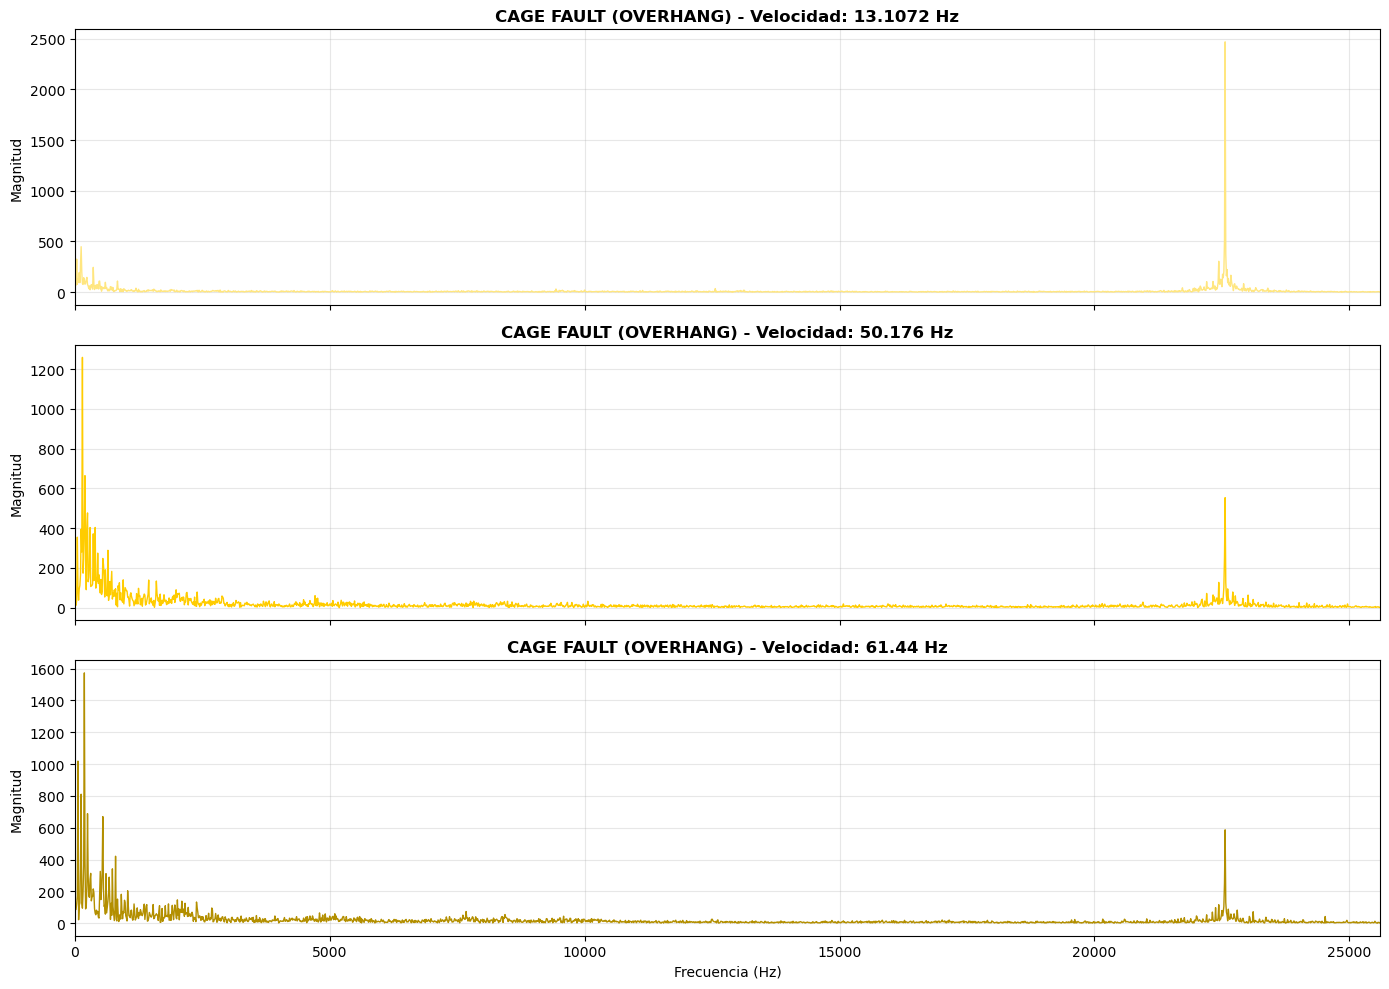

In [34]:
condicion_cage_over = (df_all['label'] == 'cage_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False))
df_cage_over = df_all[condicion_cage_over]

archivos_cage_over = df_cage_over['source_file'].unique()

archivos_ordenados_cage_over = sorted(archivos_cage_over, key=extraer_velocidad)
archivos_sel_cage_over = [
    archivos_ordenados_cage_over[0], 
    archivos_ordenados_cage_over[len(archivos_ordenados_cage_over)//2], 
    archivos_ordenados_cage_over[-1]
]

colores_cage_over = ["#ffe680", "#ffcc00", "#b38f00"] 

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, archivo in enumerate(archivos_sel_cage_over):
    signal_cruda = df_cage_over[df_cage_over["source_file"] == archivo]["acc_under_axial"].values[:n_fft]
    
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0
    
    axs[i].plot(rfreqs, rfft_mag, color=colores_cage_over[i], linewidth=1)
    vel_hz = extraer_velocidad(archivo)
    axs[i].set_title(f"CAGE FAULT (OVERHANG) - Velocidad: {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Magnitud")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[2].set_xlabel("Frecuencia (Hz)")
plt.tight_layout()
plt.show()

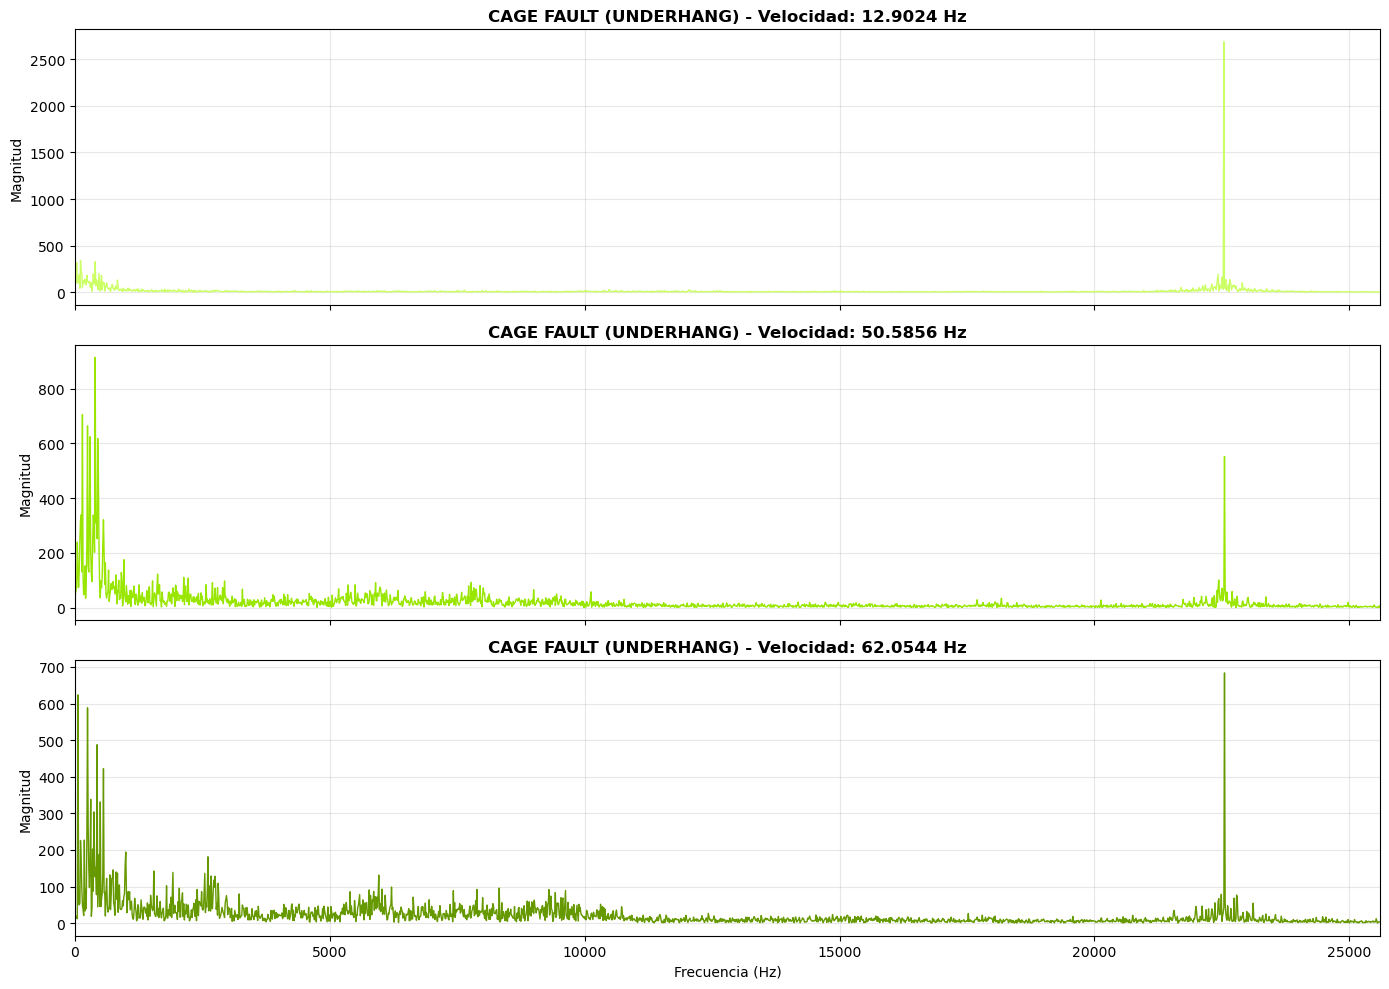

In [35]:
condicion_cage_under = (df_all['label'] == 'cage_fault') & (df_all['source_file'].str.contains('underhang', case=False, na=False))
df_cage_under = df_all[condicion_cage_under]

archivos_cage_under = df_cage_under['source_file'].unique()

archivos_ordenados_cage_under = sorted(archivos_cage_under, key=extraer_velocidad)
archivos_sel_cage_under = [
    archivos_ordenados_cage_under[0], 
    archivos_ordenados_cage_under[len(archivos_ordenados_cage_under)//2], 
    archivos_ordenados_cage_under[-1]
]

colores_cage_under = ["#ccff66", "#99e600", "#669900"]

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, archivo in enumerate(archivos_sel_cage_under):
    signal_cruda = df_cage_under[df_cage_under["source_file"] == archivo]["acc_under_axial"].values[:n_fft]
    
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0
    
    axs[i].plot(rfreqs, rfft_mag, color=colores_cage_under[i], linewidth=1)
    vel_hz = extraer_velocidad(archivo)
    axs[i].set_title(f"CAGE FAULT (UNDERHANG) - Velocidad: {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Magnitud")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[2].set_xlabel("Frecuencia (Hz)")
plt.tight_layout()
plt.show()

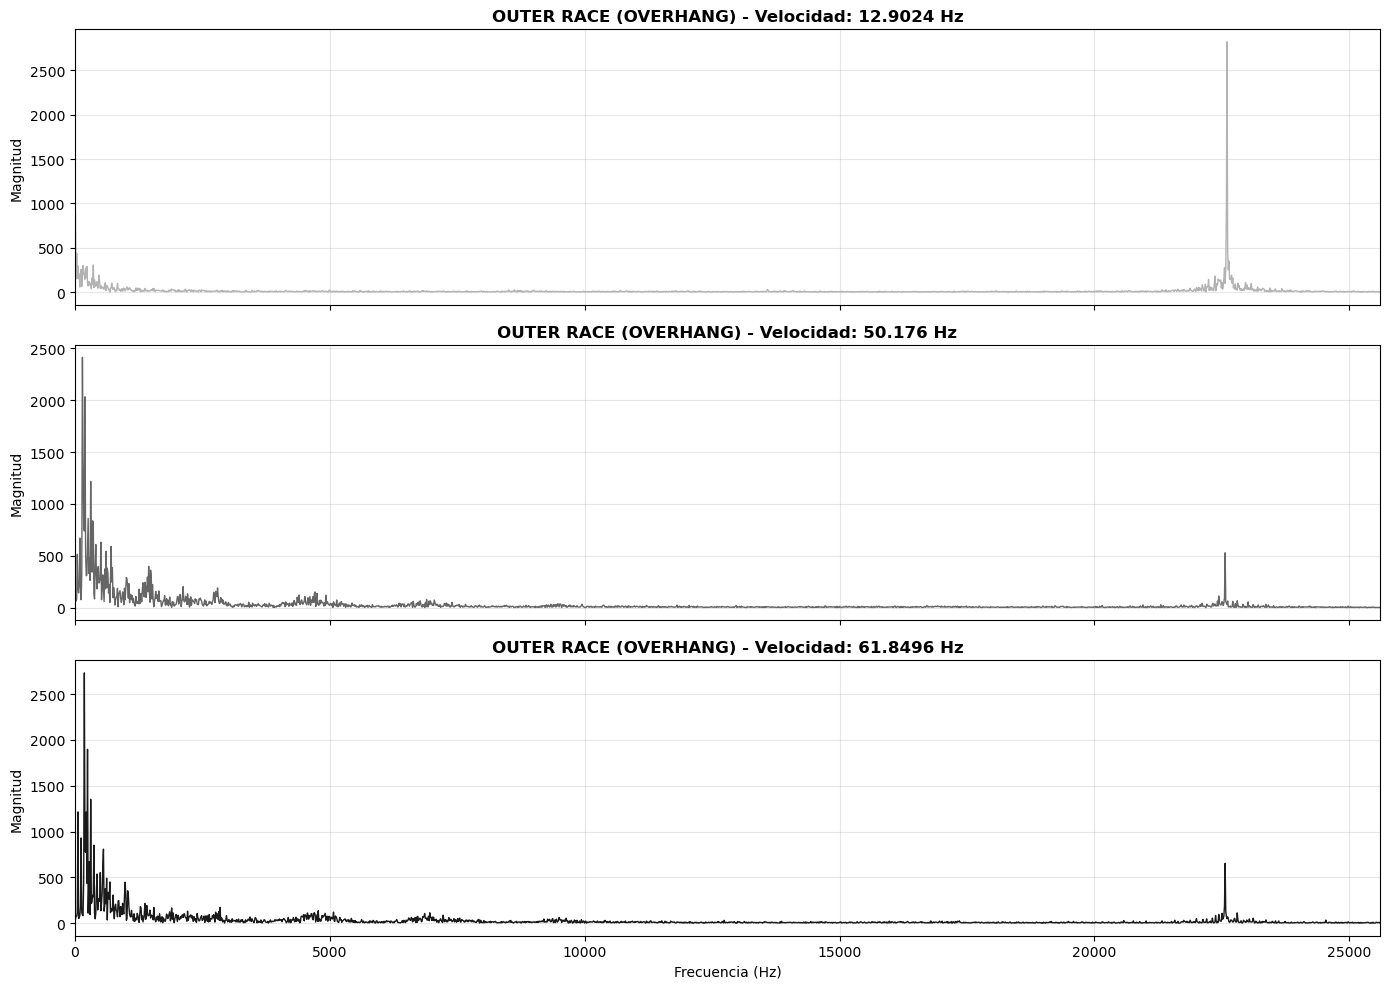

In [36]:
condicion_outer_over = (df_all['label'] == 'outer_race') & (df_all['source_file'].str.contains('overhang', case=False, na=False))
df_outer_over = df_all[condicion_outer_over]

archivos_outer_over = df_outer_over['source_file'].unique()

archivos_ordenados_outer_over = sorted(archivos_outer_over, key=extraer_velocidad)
archivos_sel_outer_over = [
    archivos_ordenados_outer_over[0], 
    archivos_ordenados_outer_over[len(archivos_ordenados_outer_over)//2], 
    archivos_ordenados_outer_over[-1]
]

colores_outer_over = ["#b3b3b3", "#666666", "#1a1a1a"]

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, archivo in enumerate(archivos_sel_outer_over):
    signal_cruda = df_outer_over[df_outer_over["source_file"] == archivo]["acc_under_axial"].values[:n_fft]
    
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0
    
    axs[i].plot(rfreqs, rfft_mag, color=colores_outer_over[i], linewidth=1)
    vel_hz = extraer_velocidad(archivo)
    axs[i].set_title(f"OUTER RACE (OVERHANG) - Velocidad: {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Magnitud")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[2].set_xlabel("Frecuencia (Hz)")
plt.tight_layout()
plt.show()

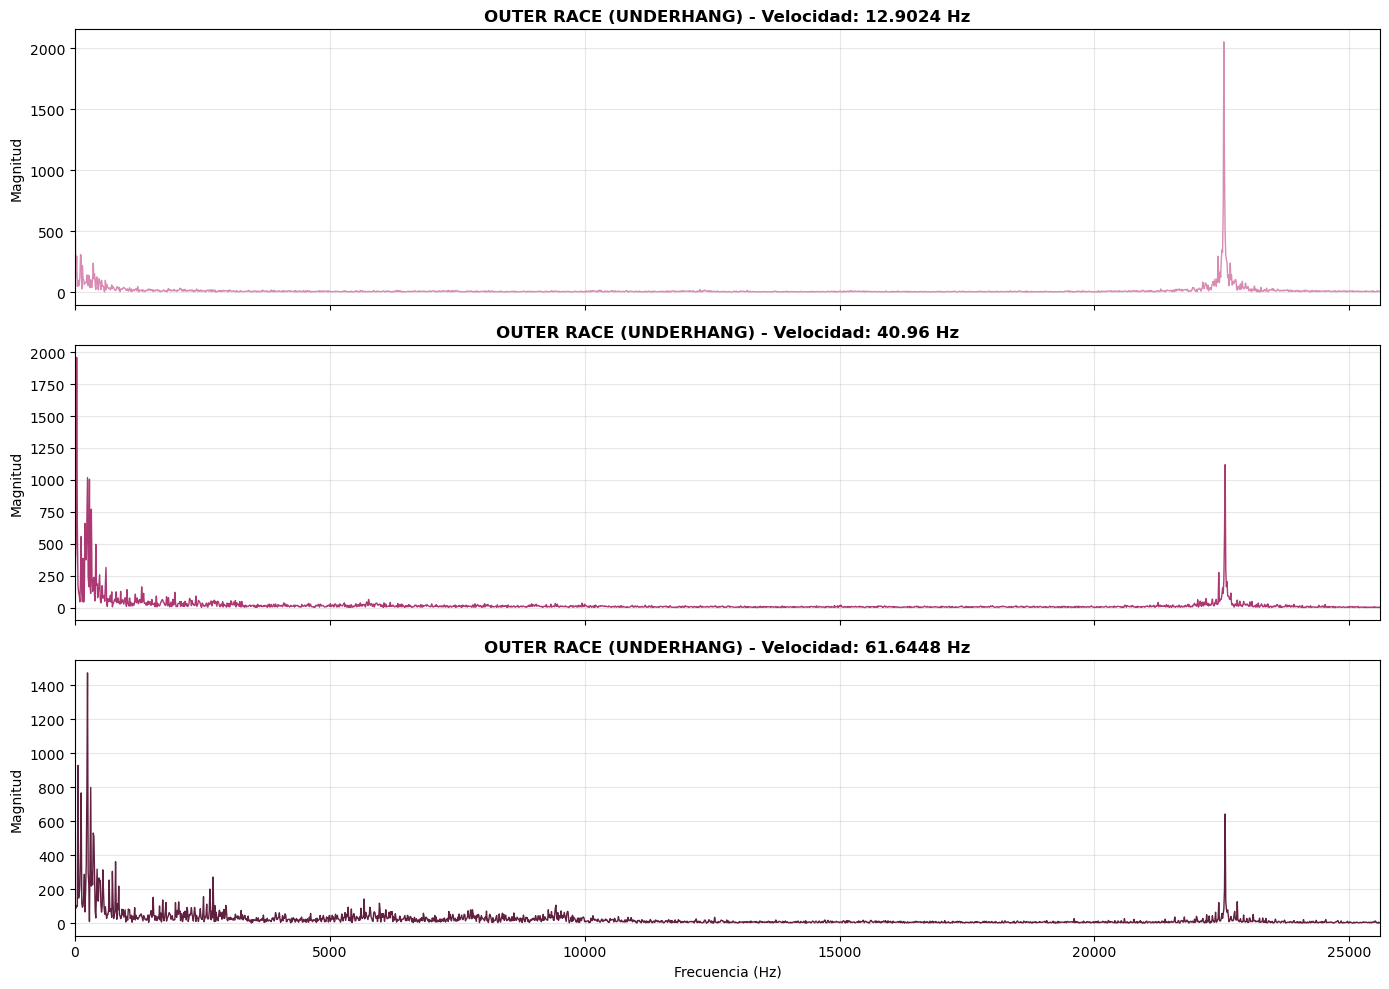

In [37]:
condicion_outer_under = (df_all['label'] == 'outer_race') & (df_all['source_file'].str.contains('underhang', case=False, na=False))
df_outer_under = df_all[condicion_outer_under]

archivos_outer_under = df_outer_under['source_file'].unique()

archivos_ordenados_outer_under = sorted(archivos_outer_under, key=extraer_velocidad)
archivos_sel_outer_under = [
    archivos_ordenados_outer_under[0], 
    archivos_ordenados_outer_under[len(archivos_ordenados_outer_under)//2], 
    archivos_ordenados_outer_under[-1]
]

colores_outer_under = ["#d98cb3", "#ac3973", "#602040"] 

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, archivo in enumerate(archivos_sel_outer_under):
    signal_cruda = df_outer_under[df_outer_under["source_file"] == archivo]["acc_under_axial"].values[:n_fft]
    
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0 
    
    axs[i].plot(rfreqs, rfft_mag, color=colores_outer_under[i], linewidth=1)
    vel_hz = extraer_velocidad(archivo)
    axs[i].set_title(f"OUTER RACE (UNDERHANG) - Velocidad: {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Magnitud")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[2].set_xlabel("Frecuencia (Hz)")
plt.tight_layout()
plt.show()

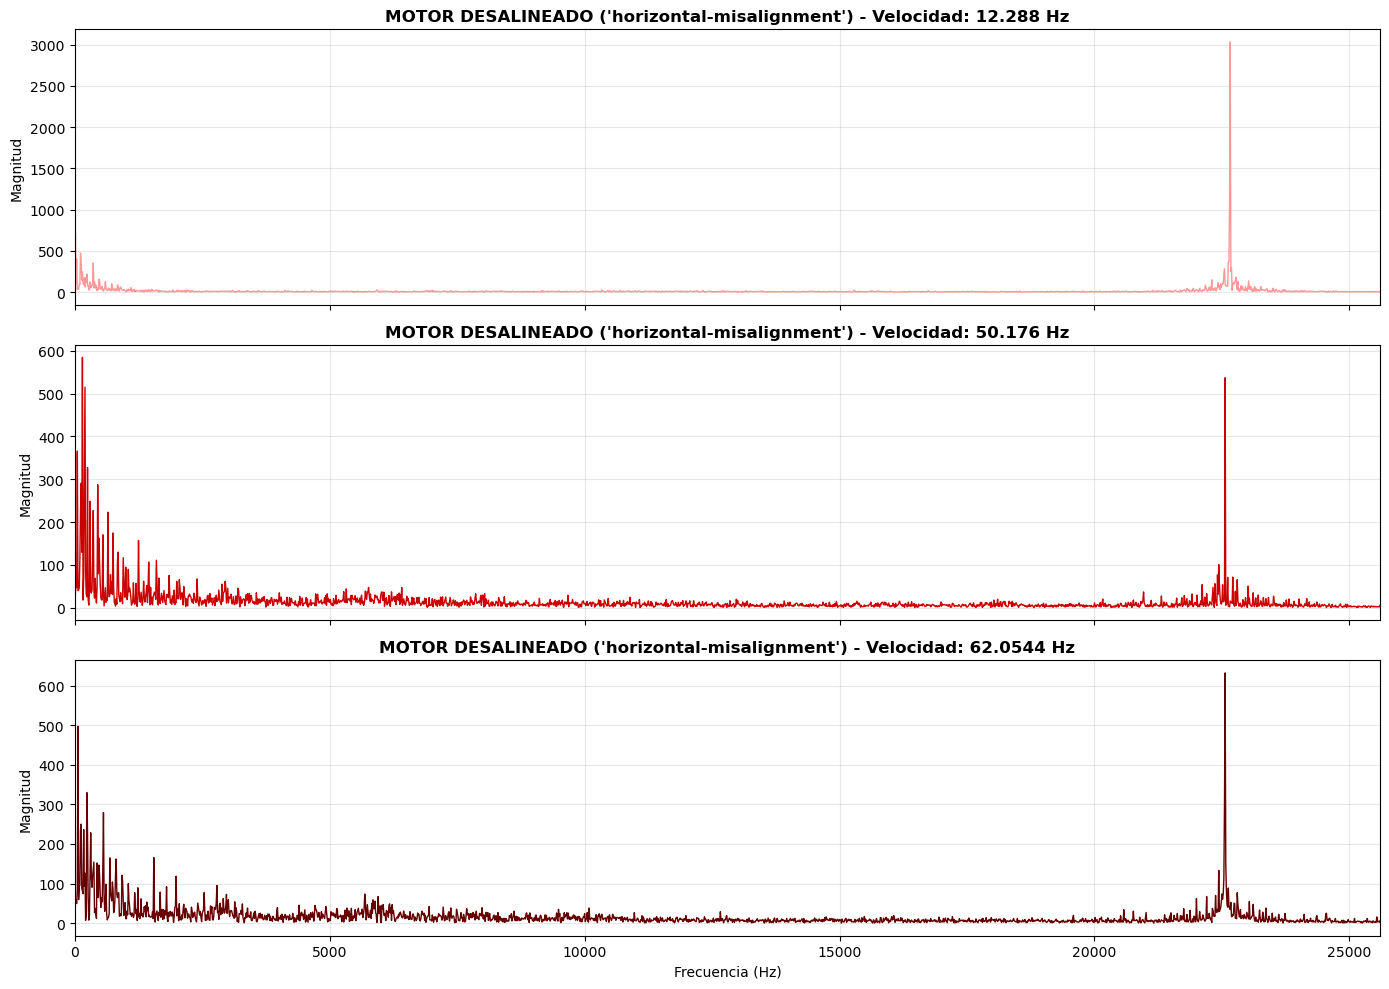

In [38]:
df_mis = df_all[df_all['label'] == 'horizontal-misalignment']
archivos_mis = df_mis['source_file'].unique()

archivos_ordenados_mis = sorted(archivos_mis, key=extraer_velocidad)
archivos_sel_mis = [
    archivos_ordenados_mis[0], 
    archivos_ordenados_mis[len(archivos_ordenados_mis)//2], 
    archivos_ordenados_mis[-1]
]

colores_mis = ["#ff9999", "#cc0000", "#660000"] 

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, archivo in enumerate(archivos_sel_mis):
    signal_cruda = df_mis[df_mis["source_file"] == archivo]["acc_under_axial"].values[:n_fft]
    
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0 
    
    axs[i].plot(rfreqs, rfft_mag, color=colores_mis[i], linewidth=1)
    vel_hz = extraer_velocidad(archivo)
    axs[i].set_title(f"MOTOR DESALINEADO ('horizontal-misalignment') - Velocidad: {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Magnitud")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[2].set_xlabel("Frecuencia (Hz)")
plt.tight_layout()
plt.show()

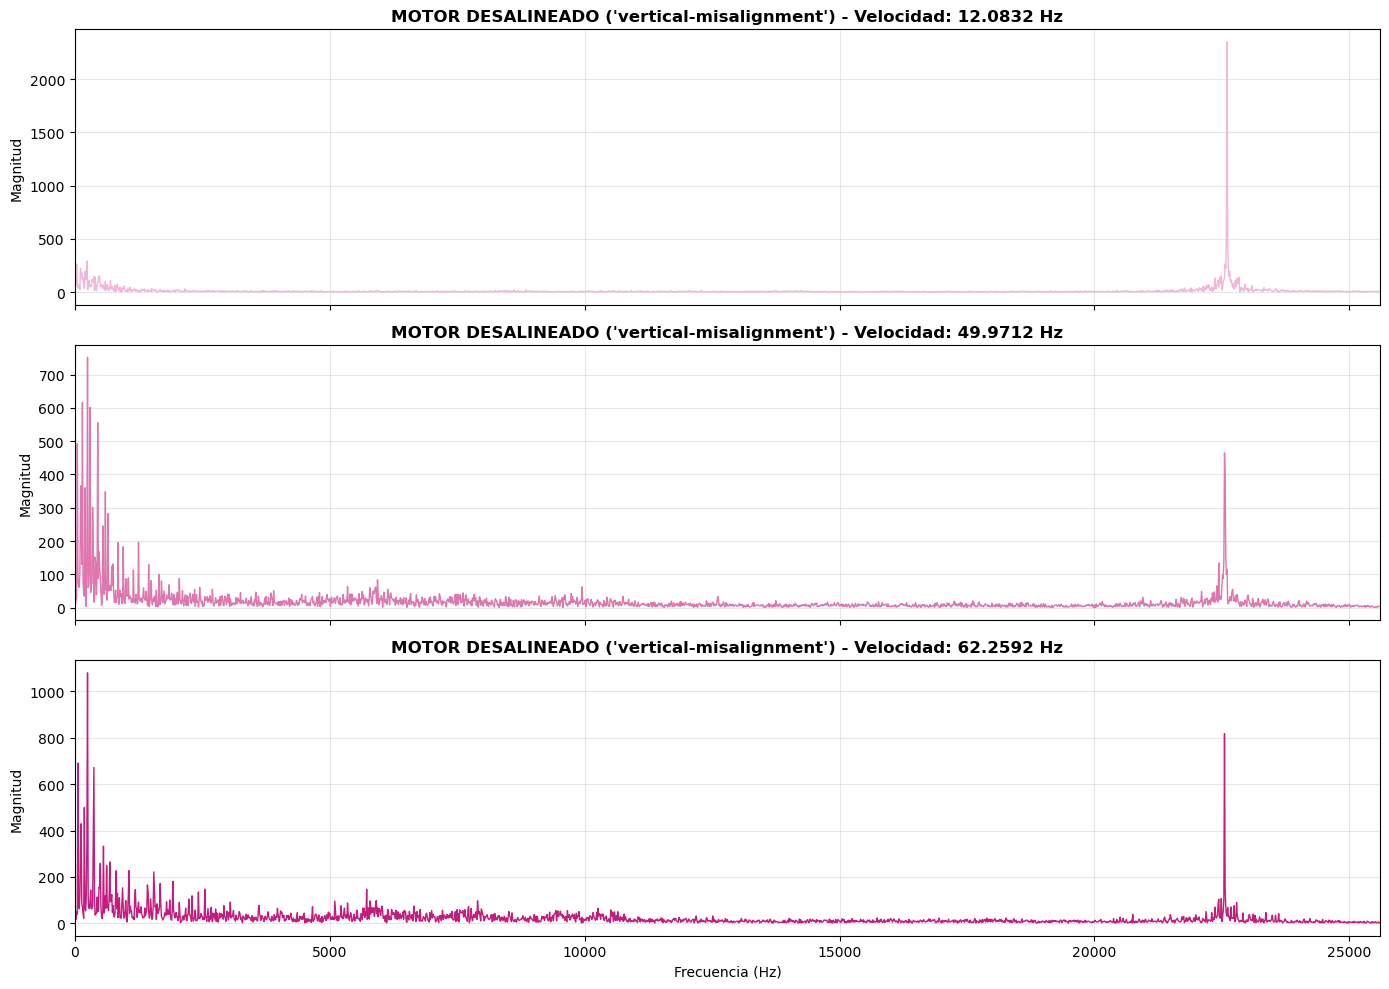

In [39]:
df_v_mis = df_all[df_all['label'] == 'vertical-misalignment']
archivos_v_mis = df_v_mis['source_file'].unique()

archivos_ordenados_v_mis = sorted(archivos_v_mis, key=extraer_velocidad)
archivos_sel_v_mis = [
    archivos_ordenados_v_mis[0], 
    archivos_ordenados_v_mis[len(archivos_ordenados_v_mis)//2], 
    archivos_ordenados_v_mis[-1]
]

colores_v_mis = ["#f1b6da", "#de77ae", "#c51b7d"] 

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, archivo in enumerate(archivos_sel_v_mis):
    signal_cruda = df_v_mis[df_v_mis["source_file"] == archivo]["acc_under_axial"].values[:n_fft]
    
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0 
    
    axs[i].plot(rfreqs, rfft_mag, color=colores_v_mis[i], linewidth=1)
    vel_hz = extraer_velocidad(archivo)
    axs[i].set_title(f"MOTOR DESALINEADO ('vertical-misalignment') - Velocidad: {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Magnitud")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[2].set_xlabel("Frecuencia (Hz)")
plt.tight_layout()
plt.show()

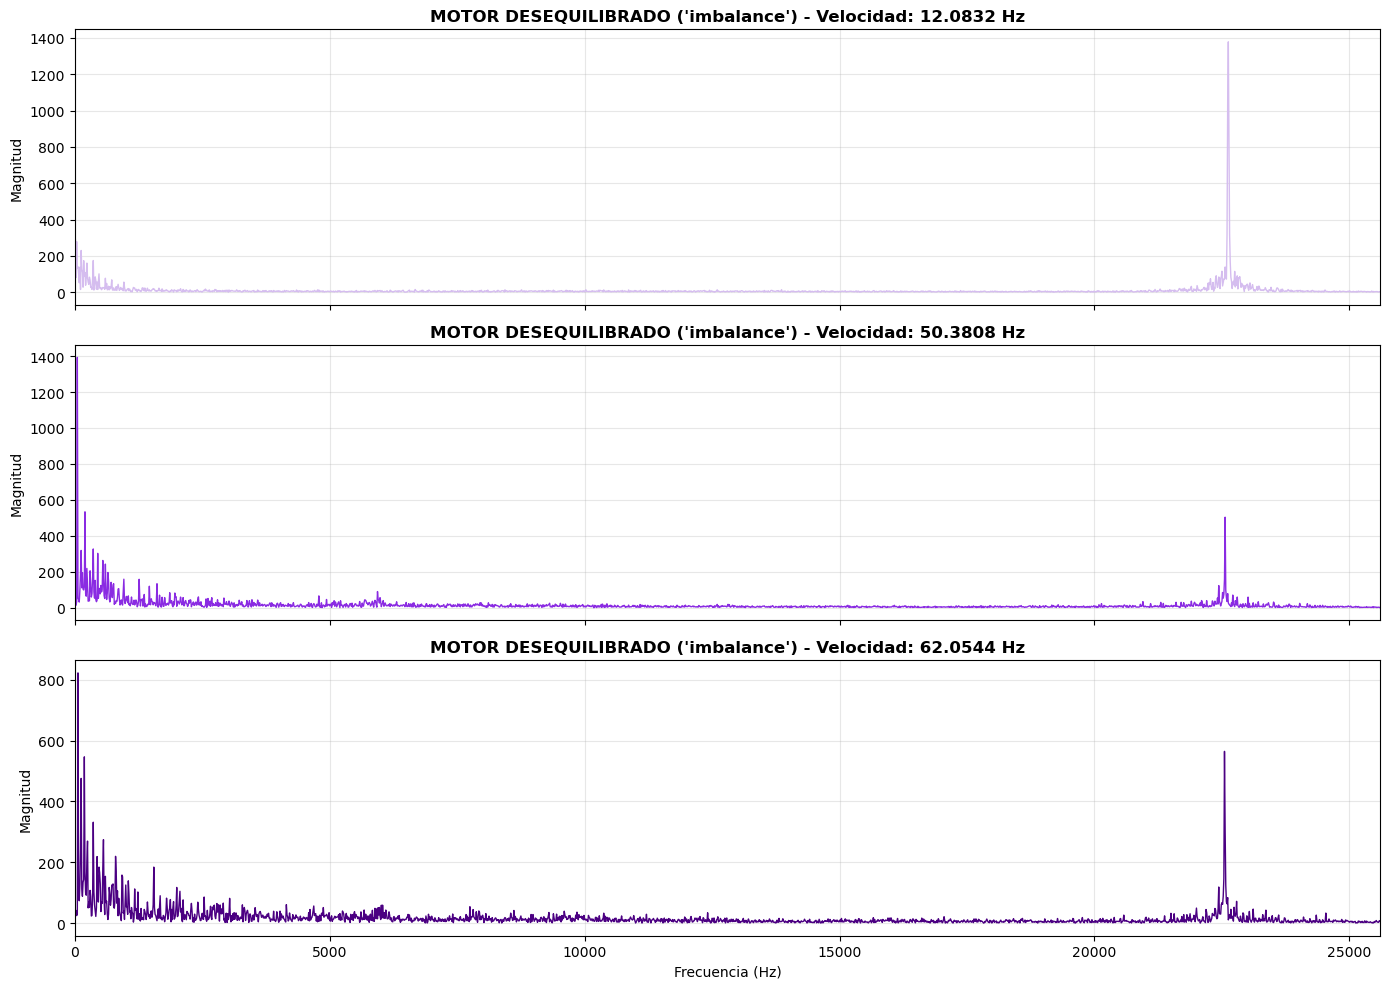

In [40]:
df_imb = df_all[df_all['label'] == 'imbalance']
archivos_imb = df_imb['source_file'].unique()

archivos_ordenados_imb = sorted(archivos_imb, key=extraer_velocidad)
archivos_sel_imb = [
    archivos_ordenados_imb[0], 
    archivos_ordenados_imb[len(archivos_ordenados_imb)//2], 
    archivos_ordenados_imb[-1]
]

colores_imb = ["#d5bdef", "#8a2be2", "#4b0082"] 

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, archivo in enumerate(archivos_sel_imb):
    signal_cruda = df_imb[df_imb["source_file"] == archivo]["acc_under_axial"].values[:n_fft]
    
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0 
    
    axs[i].plot(rfreqs, rfft_mag, color=colores_imb[i], linewidth=1)
    vel_hz = extraer_velocidad(archivo)
    axs[i].set_title(f"MOTOR DESEQUILIBRADO ('imbalance') - Velocidad: {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Magnitud")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[2].set_xlabel("Frecuencia (Hz)")
plt.tight_layout()
plt.show()

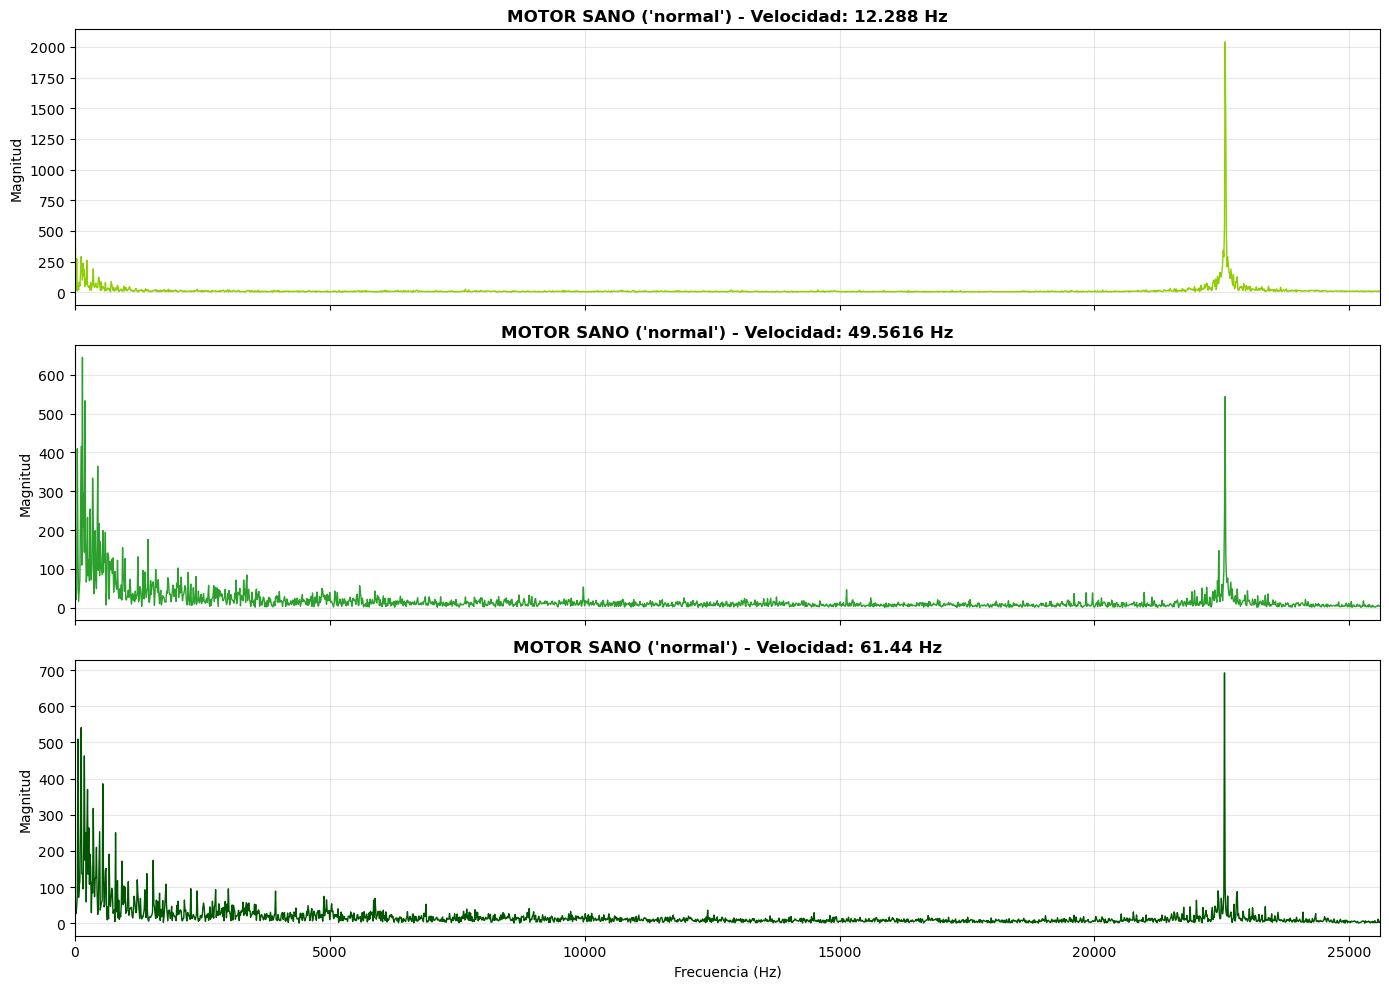

In [41]:
df_sano = df_all[df_all['label'] == 'normal']
archivos_sano = df_sano['source_file'].unique()

archivos_ordenados_sano = sorted(archivos_sano, key=extraer_velocidad)
archivos_sel_sano = [
    archivos_ordenados_sano[0], 
    archivos_ordenados_sano[len(archivos_ordenados_sano)//2], 
    archivos_ordenados_sano[-1]
]

colores_sano = ["#8fce00", "#2ca02c", "#005500"] 

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, archivo in enumerate(archivos_sel_sano):
    signal_cruda = df_sano[df_sano["source_file"] == archivo]["acc_under_axial"].values[:n_fft]
    
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0 
    
    axs[i].plot(rfreqs, rfft_mag, color=colores_sano[i], linewidth=1)
    vel_hz = extraer_velocidad(archivo)
    axs[i].set_title(f"MOTOR SANO ('normal') - Velocidad: {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Magnitud")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[2].set_xlabel("Frecuencia (Hz)")
plt.tight_layout()
plt.show()

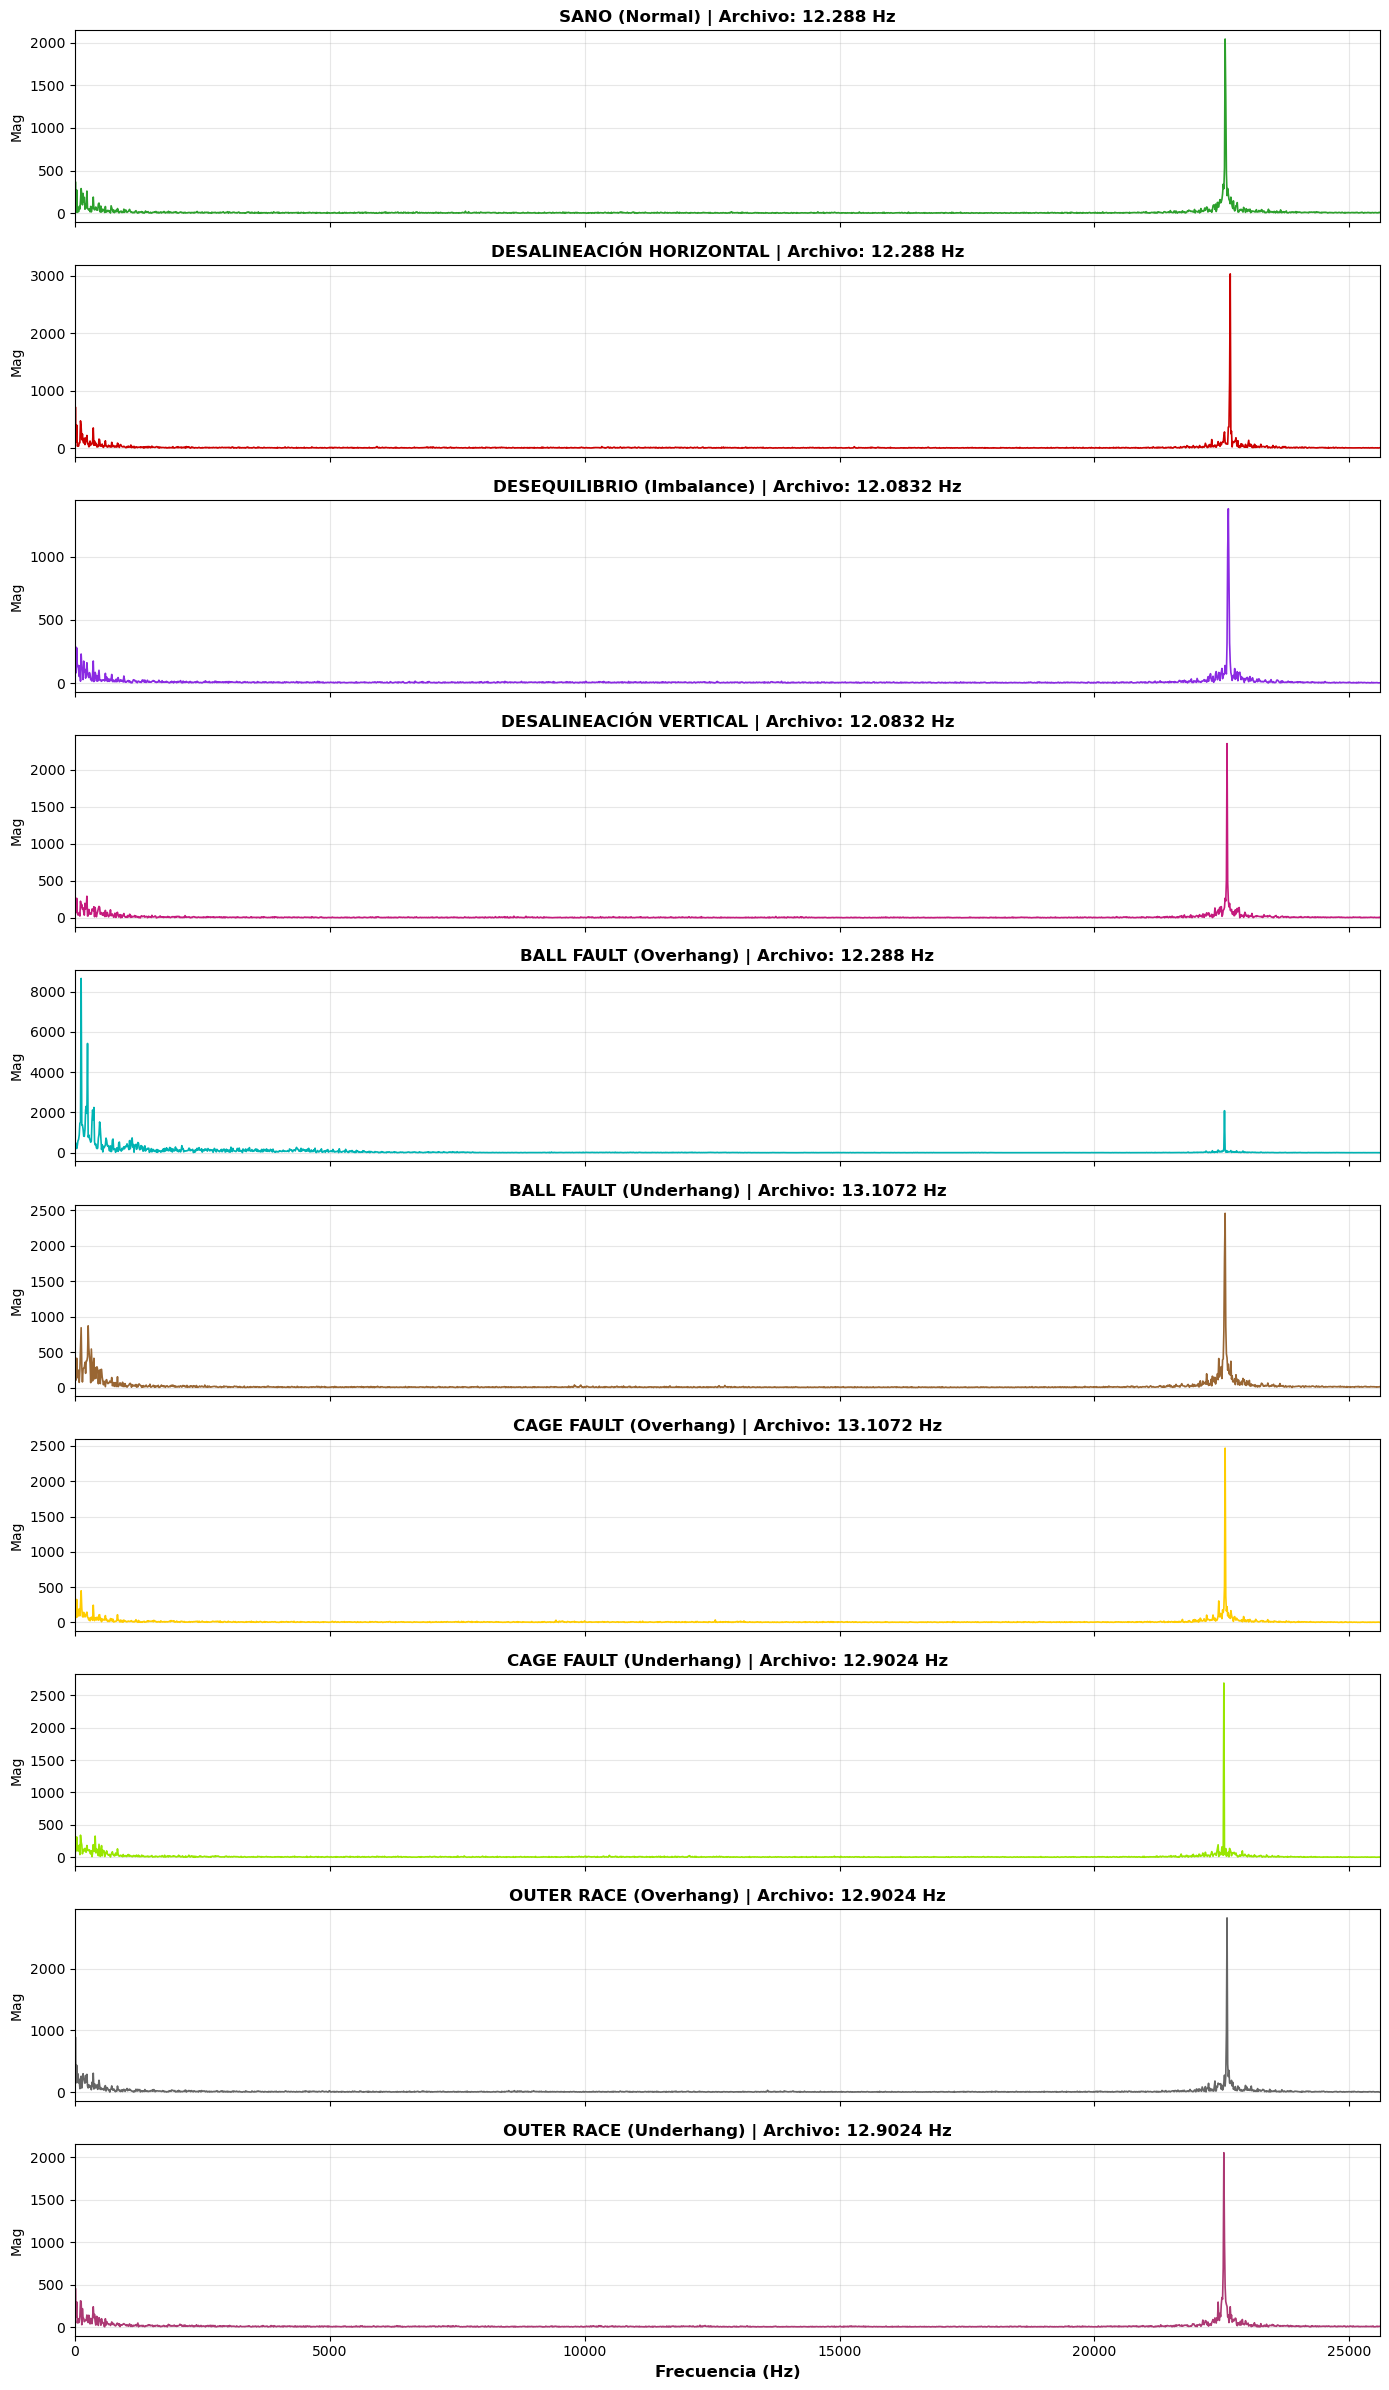

In [42]:
categorias = [
    ("SANO (Normal)", df_all['label'] == 'normal', "#2ca02c"), # Verde
    ("DESALINEACIÓN HORIZONTAL", df_all['label'] == 'horizontal-misalignment', "#cc0000"), # Rojo
    ("DESEQUILIBRIO (Imbalance)", df_all['label'] == 'imbalance', "#8a2be2"), # Morado
    ("DESALINEACIÓN VERTICAL", df_all['label'] == 'vertical-misalignment', "#c51b7d"), # Magenta
    ("BALL FAULT (Overhang)", (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#00b3b3"), # Turquesa
    ("BALL FAULT (Underhang)", (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#996633"), # Marrón
    ("CAGE FAULT (Overhang)", (df_all['label'] == 'cage_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#ffcc00"), # Dorado
    ("CAGE FAULT (Underhang)", (df_all['label'] == 'cage_fault') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#99e600"), # Verde Lima
    ("OUTER RACE (Overhang)", (df_all['label'] == 'outer_race') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#666666"), # Gris
    ("OUTER RACE (Underhang)", (df_all['label'] == 'outer_race') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#ac3973")  # Vino
]

fs = 51200
n_fft = 4096

fig, axs = plt.subplots(len(categorias), 1, figsize=(14, 24), sharex=True)

for i, (nombre, condicion, color) in enumerate(categorias):
    df_filtrado = df_all[condicion]
    
    if df_filtrado.empty:
        axs[i].set_title(f"{nombre} - SIN DATOS", fontweight="bold")
        continue
        
    archivos = df_filtrado['source_file'].unique()
    archivos_ordenados = sorted(archivos, key=extraer_velocidad)
    
    archivo_sel = archivos_ordenados[0]
    
    signal_cruda = df_filtrado[df_filtrado["source_file"] == archivo_sel]["acc_under_axial"].values[:n_fft]
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0 
    
    vel_hz = extraer_velocidad(archivo_sel)
    
    axs[i].plot(rfreqs, rfft_mag, color=color, linewidth=1.2)
    axs[i].set_title(f"{nombre} | Archivo: {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Mag")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[-1].set_xlabel("Frecuencia (Hz)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

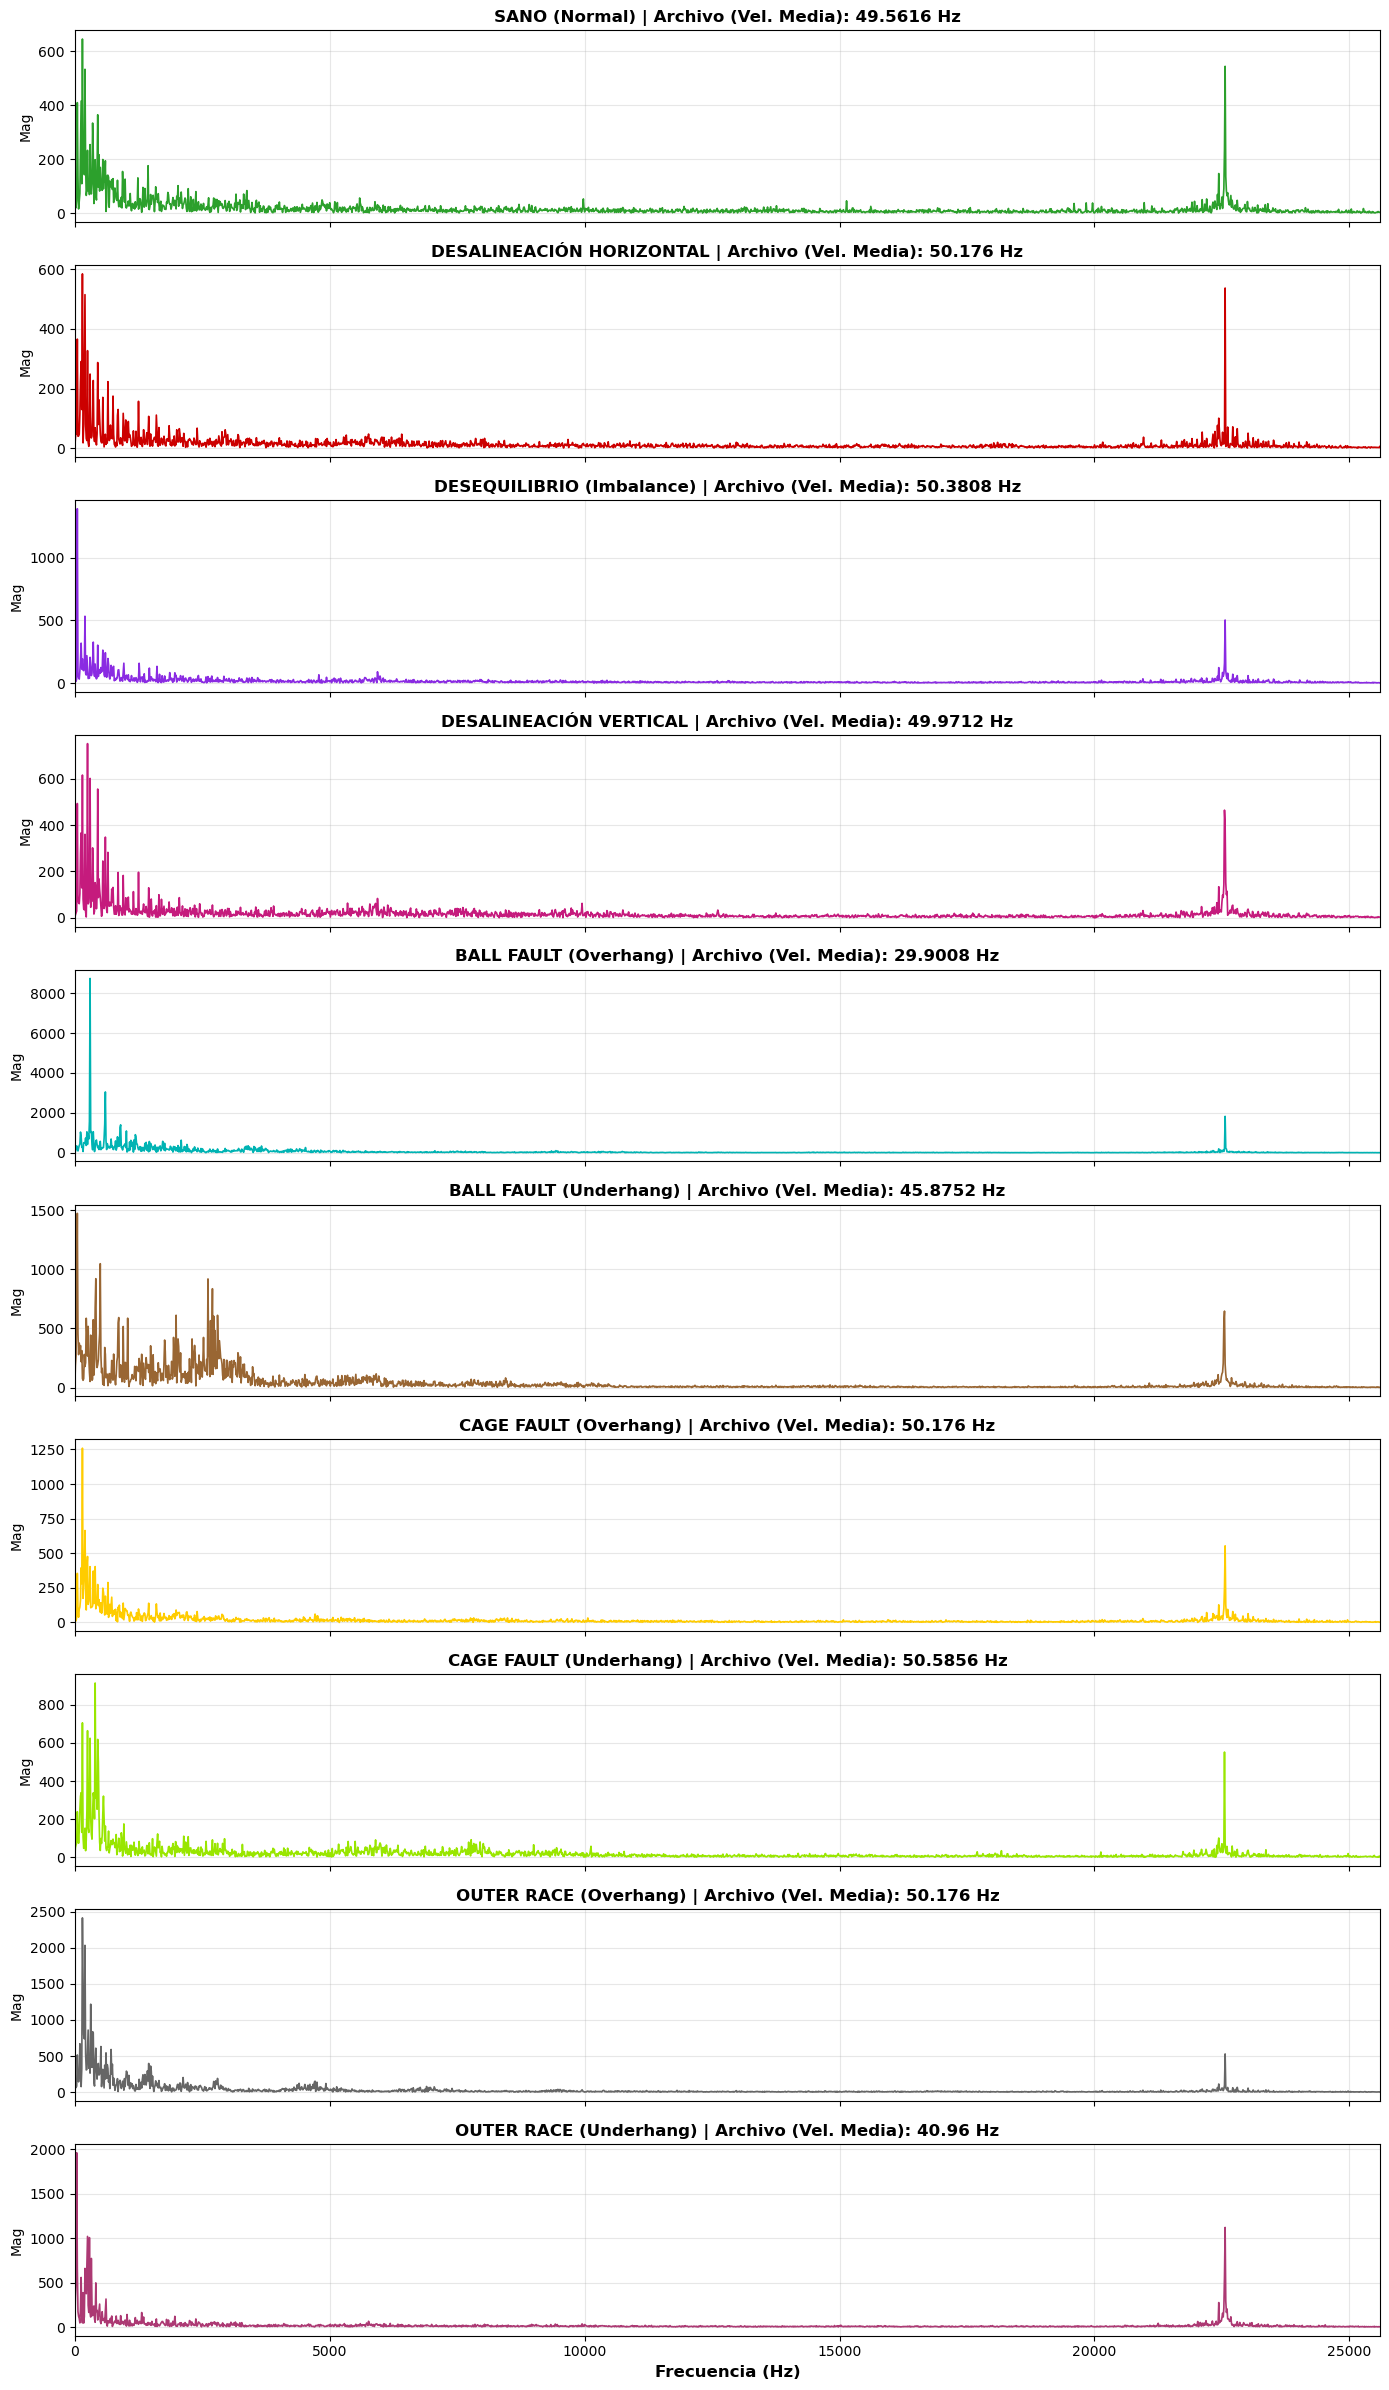

In [43]:
categorias = [
    ("SANO (Normal)", df_all['label'] == 'normal', "#2ca02c"), # Verde
    ("DESALINEACIÓN HORIZONTAL", df_all['label'] == 'horizontal-misalignment', "#cc0000"), # Rojo
    ("DESEQUILIBRIO (Imbalance)", df_all['label'] == 'imbalance', "#8a2be2"), # Morado
    ("DESALINEACIÓN VERTICAL", df_all['label'] == 'vertical-misalignment', "#c51b7d"), # Magenta
    ("BALL FAULT (Overhang)", (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#00b3b3"), # Turquesa
    ("BALL FAULT (Underhang)", (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#996633"), # Marrón
    ("CAGE FAULT (Overhang)", (df_all['label'] == 'cage_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#ffcc00"), # Dorado
    ("CAGE FAULT (Underhang)", (df_all['label'] == 'cage_fault') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#99e600"), # Verde Lima
    ("OUTER RACE (Overhang)", (df_all['label'] == 'outer_race') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#666666"), # Gris
    ("OUTER RACE (Underhang)", (df_all['label'] == 'outer_race') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#ac3973")  # Vino
]

fs = 51200
n_fft = 4096

fig, axs = plt.subplots(len(categorias), 1, figsize=(14, 24), sharex=True)

for i, (nombre, condicion, color) in enumerate(categorias):
    df_filtrado = df_all[condicion]
    
    if df_filtrado.empty:
        axs[i].set_title(f"{nombre} - SIN DATOS", fontweight="bold")
        continue
        
    archivos = df_filtrado['source_file'].unique()
    archivos_ordenados = sorted(archivos, key=extraer_velocidad)
    
    indice_medio = len(archivos_ordenados) // 2
    archivo_sel = archivos_ordenados[indice_medio]
    
    signal_cruda = df_filtrado[df_filtrado["source_file"] == archivo_sel]["acc_under_axial"].values[:n_fft]
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0 
    
    vel_hz = extraer_velocidad(archivo_sel)
    
    axs[i].plot(rfreqs, rfft_mag, color=color, linewidth=1.2)
    axs[i].set_title(f"{nombre} | Archivo (Vel. Media): {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Mag")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[-1].set_xlabel("Frecuencia (Hz)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

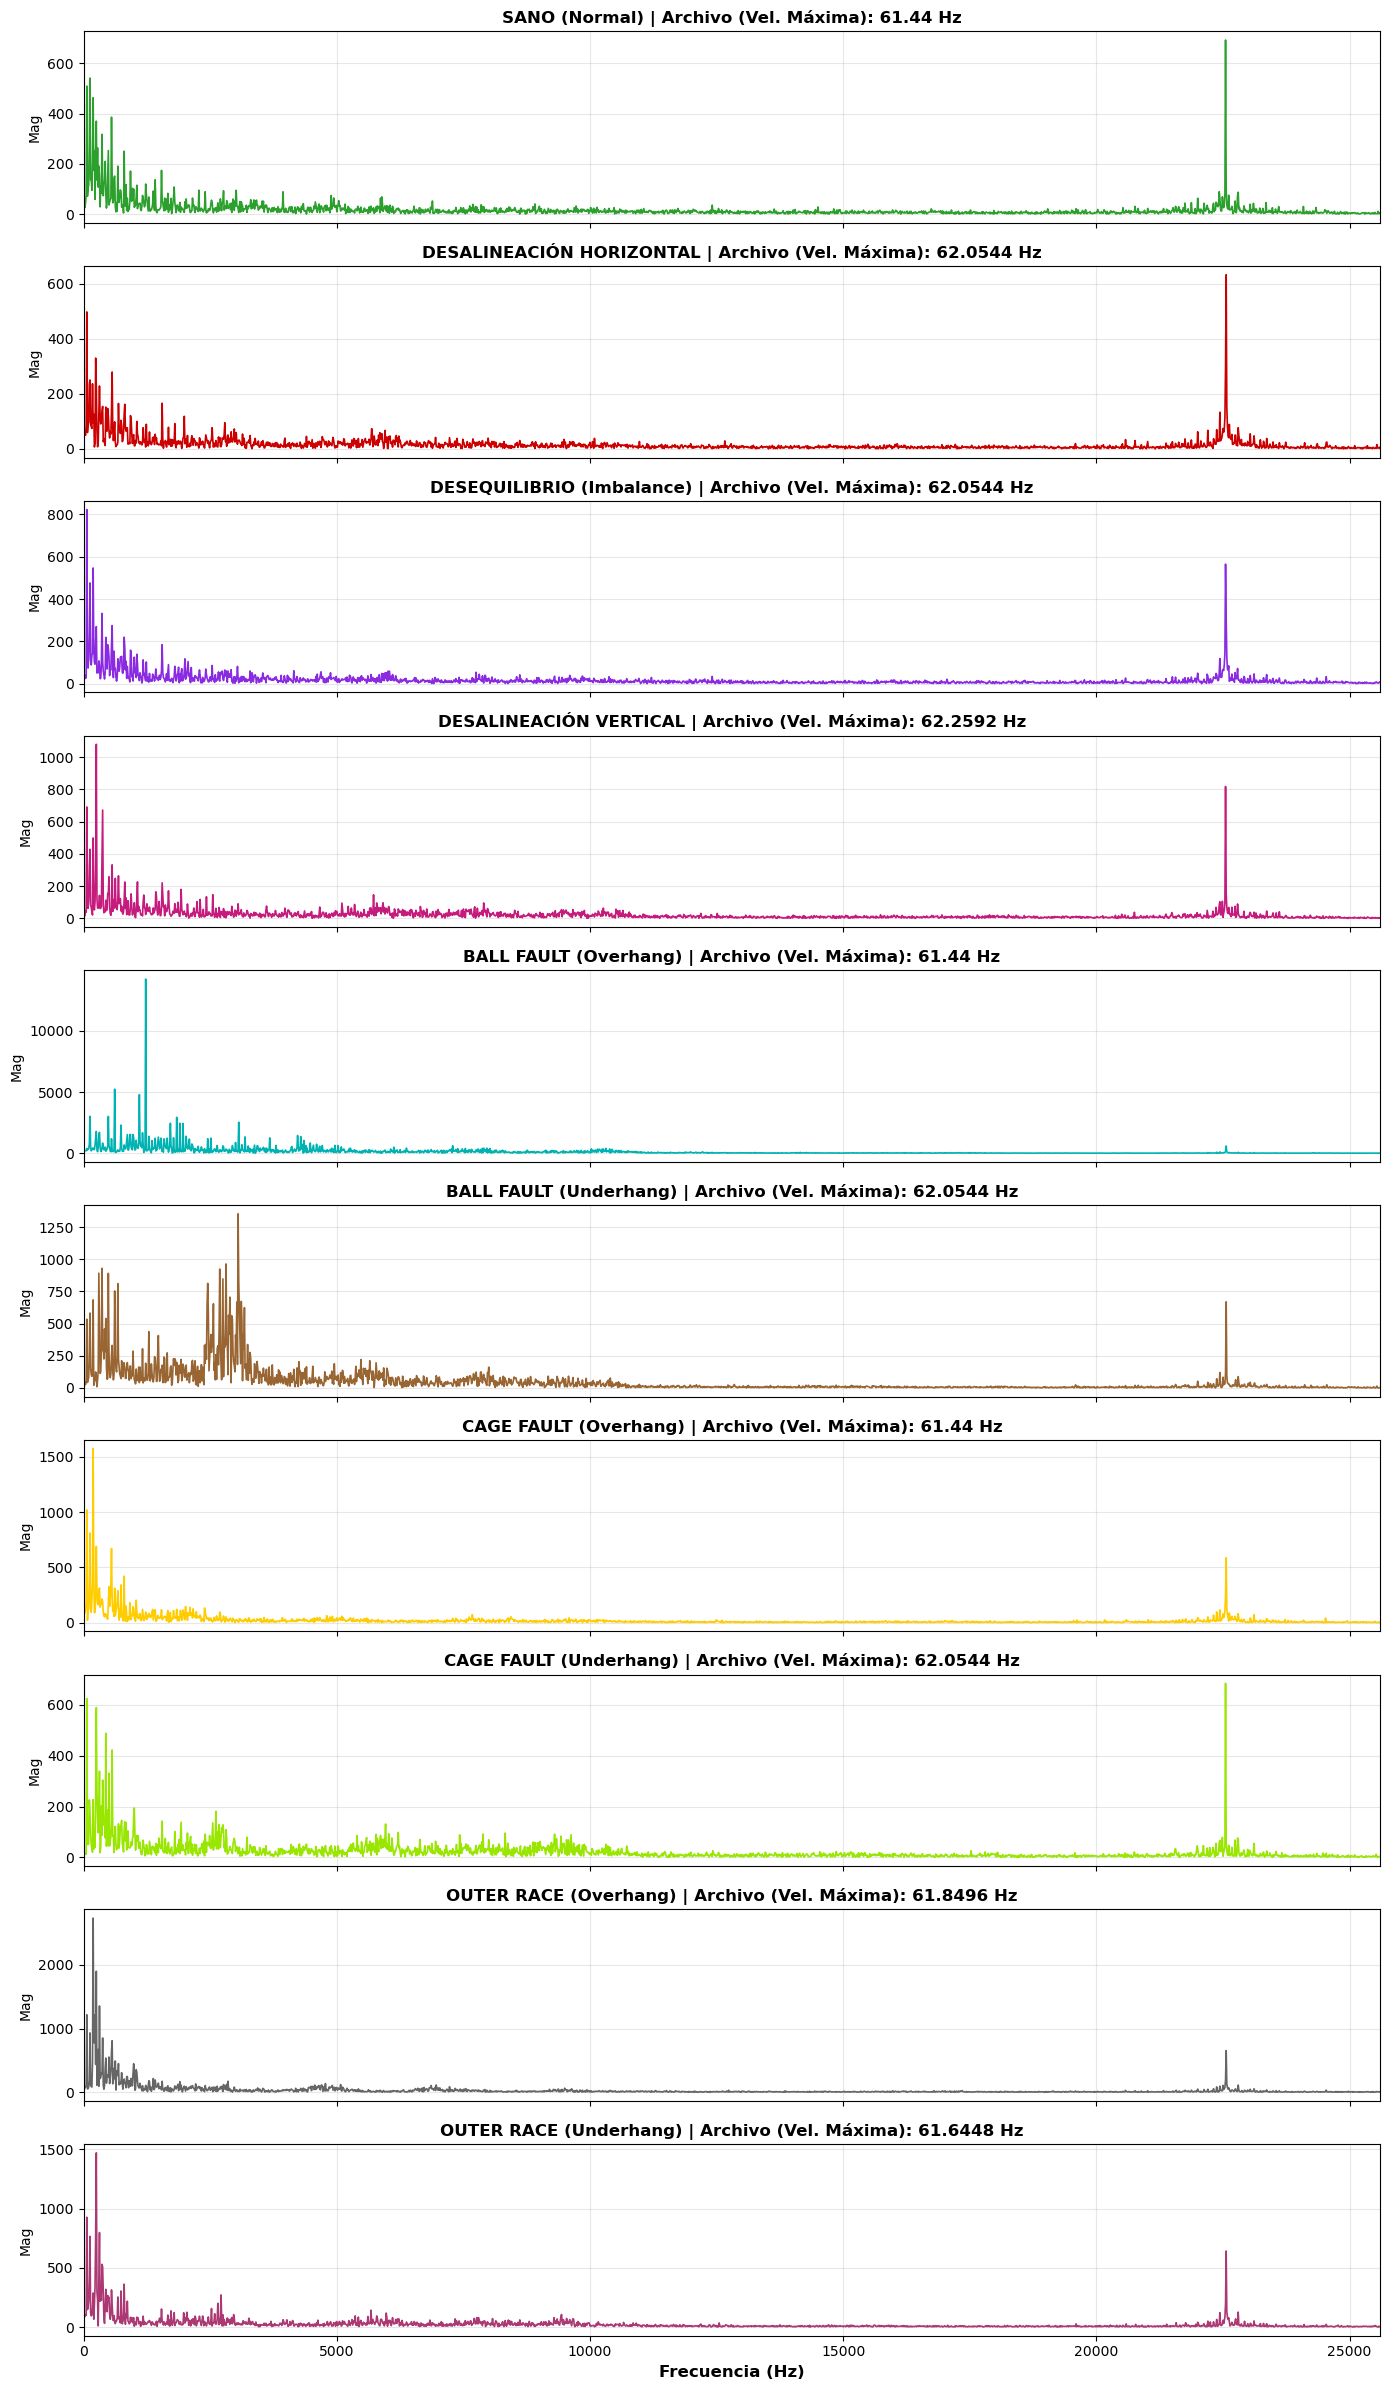

In [44]:
categorias = [
    ("SANO (Normal)", df_all['label'] == 'normal', "#2ca02c"), 
    ("DESALINEACIÓN HORIZONTAL", df_all['label'] == 'horizontal-misalignment', "#cc0000"), 
    ("DESEQUILIBRIO (Imbalance)", df_all['label'] == 'imbalance', "#8a2be2"), 
    ("DESALINEACIÓN VERTICAL", df_all['label'] == 'vertical-misalignment', "#c51b7d"), 
    ("BALL FAULT (Overhang)", (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#00b3b3"), 
    ("BALL FAULT (Underhang)", (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#996633"), 
    ("CAGE FAULT (Overhang)", (df_all['label'] == 'cage_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#ffcc00"), 
    ("CAGE FAULT (Underhang)", (df_all['label'] == 'cage_fault') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#99e600"),
    ("OUTER RACE (Overhang)", (df_all['label'] == 'outer_race') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#666666"),
    ("OUTER RACE (Underhang)", (df_all['label'] == 'outer_race') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#ac3973")  
]

fs = 51200
n_fft = 4096

fig, axs = plt.subplots(len(categorias), 1, figsize=(14, 24), sharex=True)

for i, (nombre, condicion, color) in enumerate(categorias):
    df_filtrado = df_all[condicion]
    
    if df_filtrado.empty:
        axs[i].set_title(f"{nombre} - SIN DATOS", fontweight="bold")
        continue
        
    archivos = df_filtrado['source_file'].unique()
    archivos_ordenados = sorted(archivos, key=extraer_velocidad)

    archivo_sel = archivos_ordenados[-1]
    
    signal_cruda = df_filtrado[df_filtrado["source_file"] == archivo_sel]["acc_under_axial"].values[:n_fft]
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0 
    
    vel_hz = extraer_velocidad(archivo_sel)
    
    axs[i].plot(rfreqs, rfft_mag, color=color, linewidth=1.2)
    axs[i].set_title(f"{nombre} | Archivo (Vel. Máxima): {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Mag")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[-1].set_xlabel("Frecuencia (Hz)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

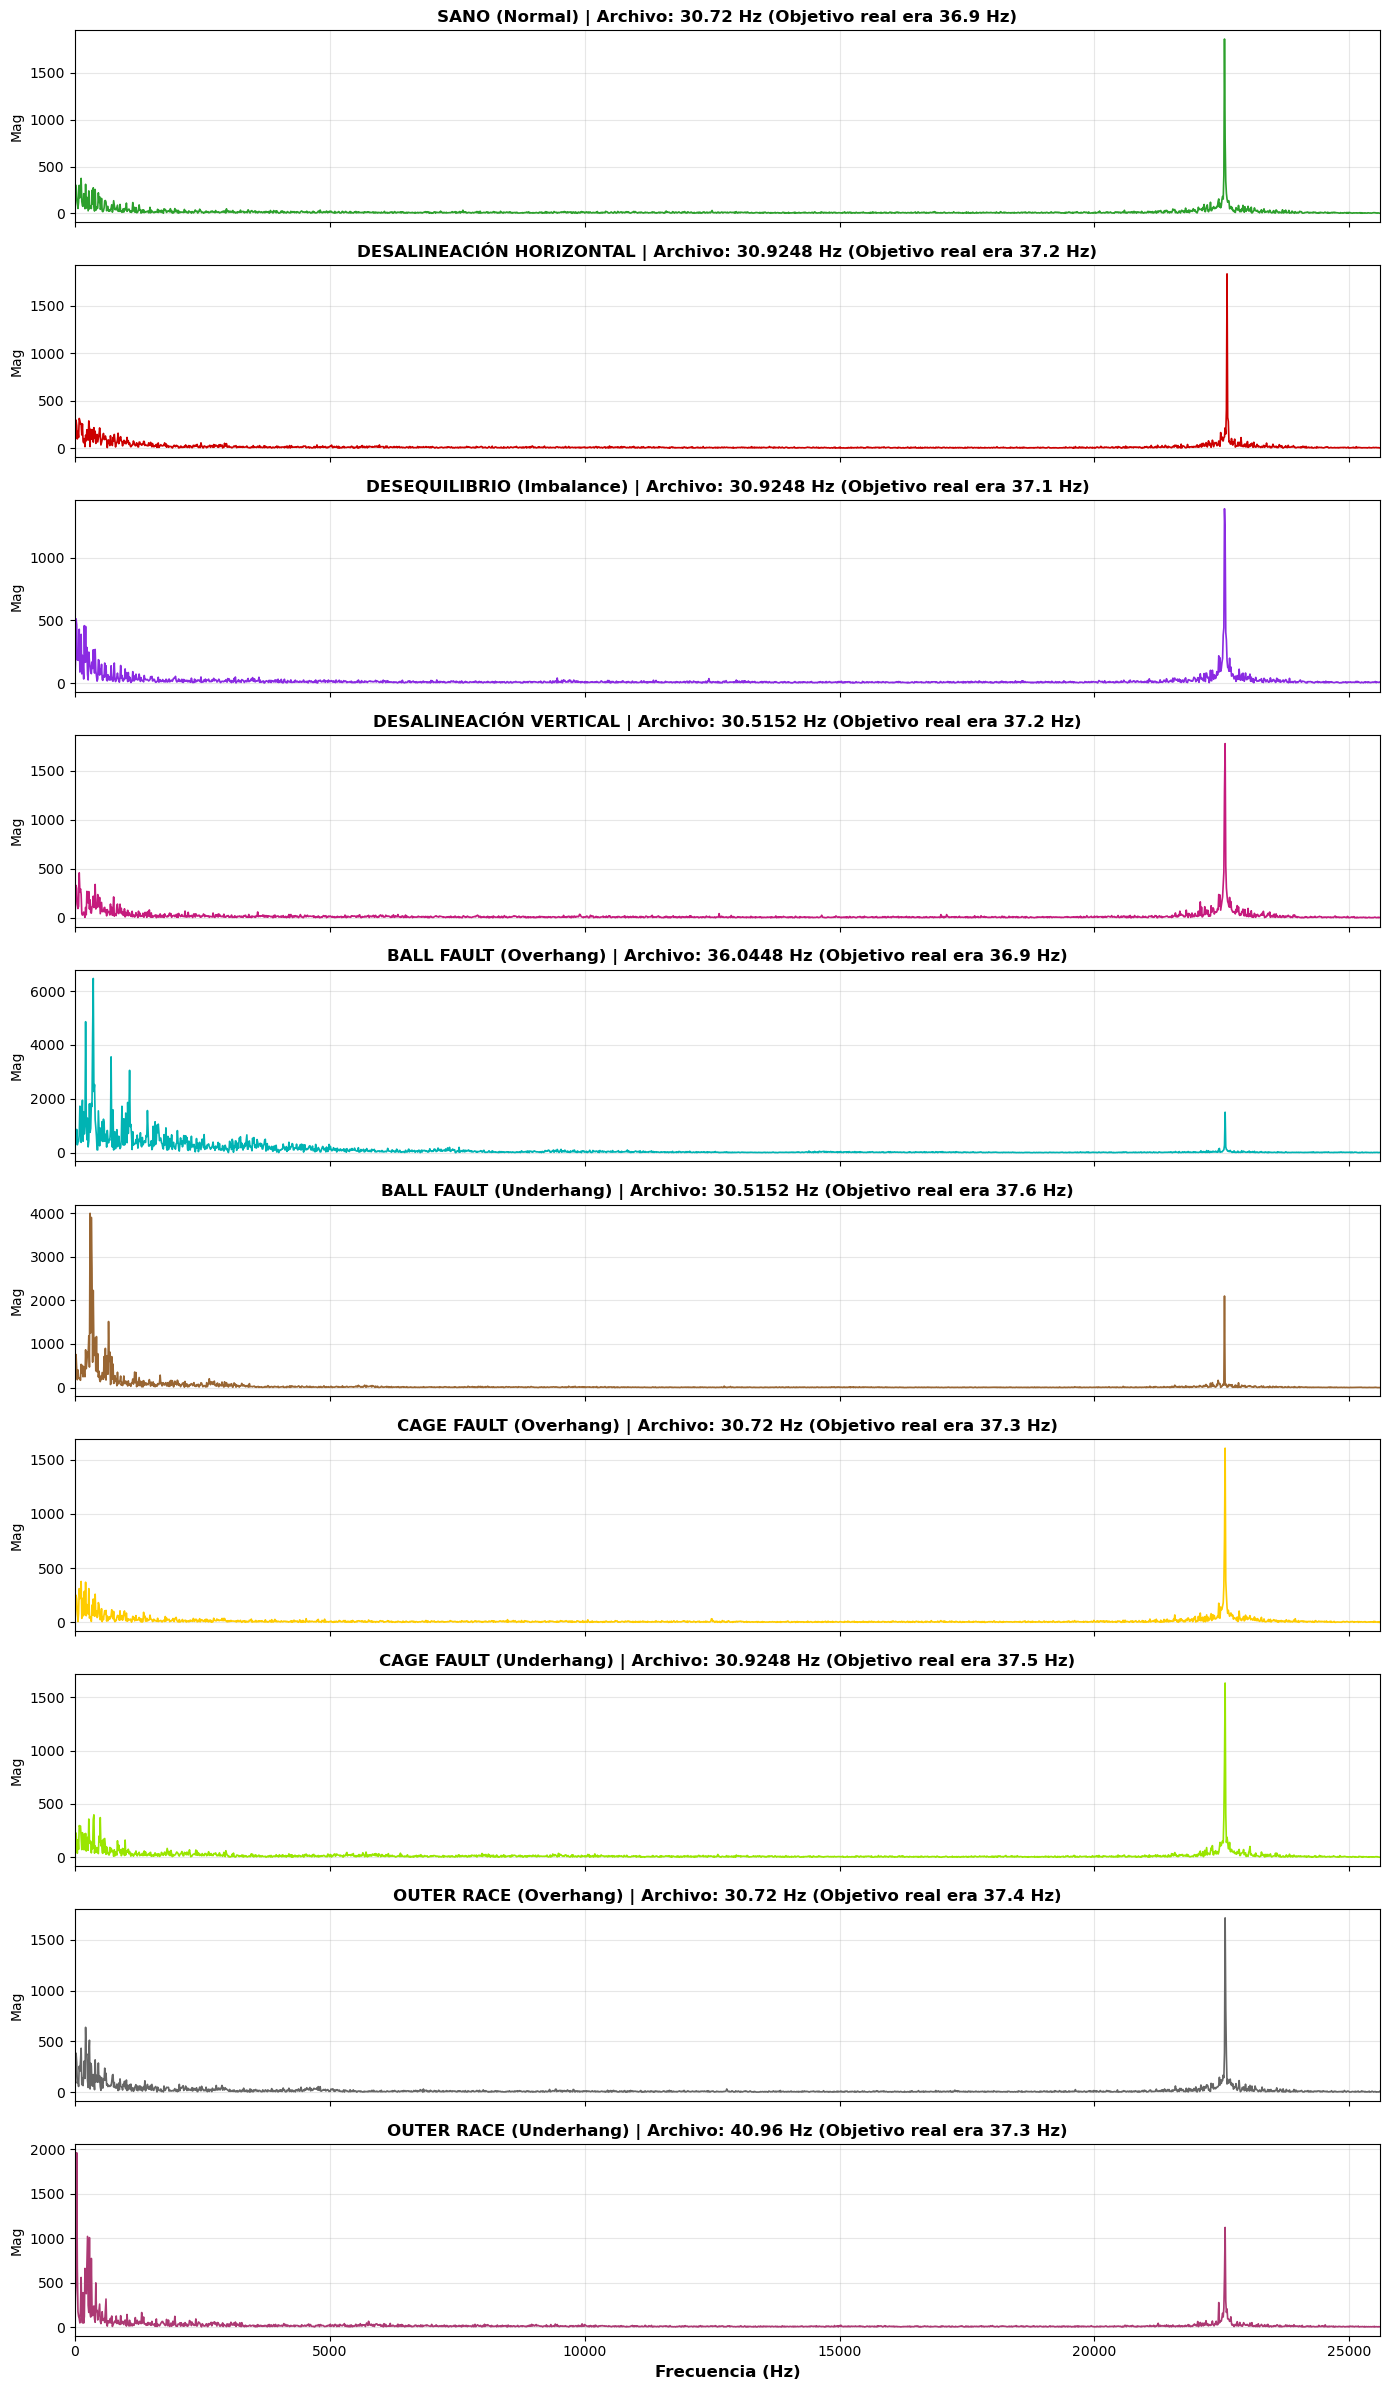

In [45]:
categorias = [
    ("SANO (Normal)", df_all['label'] == 'normal', "#2ca02c"), 
    ("DESALINEACIÓN HORIZONTAL", df_all['label'] == 'horizontal-misalignment', "#cc0000"), 
    ("DESEQUILIBRIO (Imbalance)", df_all['label'] == 'imbalance', "#8a2be2"), 
    ("DESALINEACIÓN VERTICAL", df_all['label'] == 'vertical-misalignment', "#c51b7d"), 
    ("BALL FAULT (Overhang)", (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#00b3b3"), 
    ("BALL FAULT (Underhang)", (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#996633"), 
    ("CAGE FAULT (Overhang)", (df_all['label'] == 'cage_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#ffcc00"), 
    ("CAGE FAULT (Underhang)", (df_all['label'] == 'cage_fault') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#99e600"), 
    ("OUTER RACE (Overhang)", (df_all['label'] == 'outer_race') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#666666"), 
    ("OUTER RACE (Underhang)", (df_all['label'] == 'outer_race') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#ac3973")  
]

fs = 51200
n_fft = 4096

fig, axs = plt.subplots(len(categorias), 1, figsize=(14, 24), sharex=True)

for i, (nombre, condicion, color) in enumerate(categorias):
    df_filtrado = df_all[condicion]
    
    if df_filtrado.empty:
        axs[i].set_title(f"{nombre} - SIN DATOS", fontweight="bold")
        continue
        
    archivos = df_filtrado['source_file'].unique()
    
    velocidades = [extraer_velocidad(arc) for arc in archivos]
    vel_min = min(velocidades)
    vel_max = max(velocidades)
    
    vel_objetivo = (vel_min + vel_max) / 2.0
    
    archivo_sel = min(archivos, key=lambda x: abs(extraer_velocidad(x) - vel_objetivo))
    
    vel_hz = extraer_velocidad(archivo_sel)
    
    signal_cruda = df_filtrado[df_filtrado["source_file"] == archivo_sel]["acc_under_axial"].values[:n_fft]
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0 # Seguro contra el Offset DC
    
    axs[i].plot(rfreqs, rfft_mag, color=color, linewidth=1.2)
    axs[i].set_title(f"{nombre} | Archivo: {vel_hz} Hz (Objetivo real era {vel_objetivo:.1f} Hz)", fontweight="bold")
    axs[i].set_ylabel("Mag")
    axs[i].grid(True, alpha=0.3)

plt.xlim(0, 25600)
axs[-1].set_xlabel("Frecuencia (Hz)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

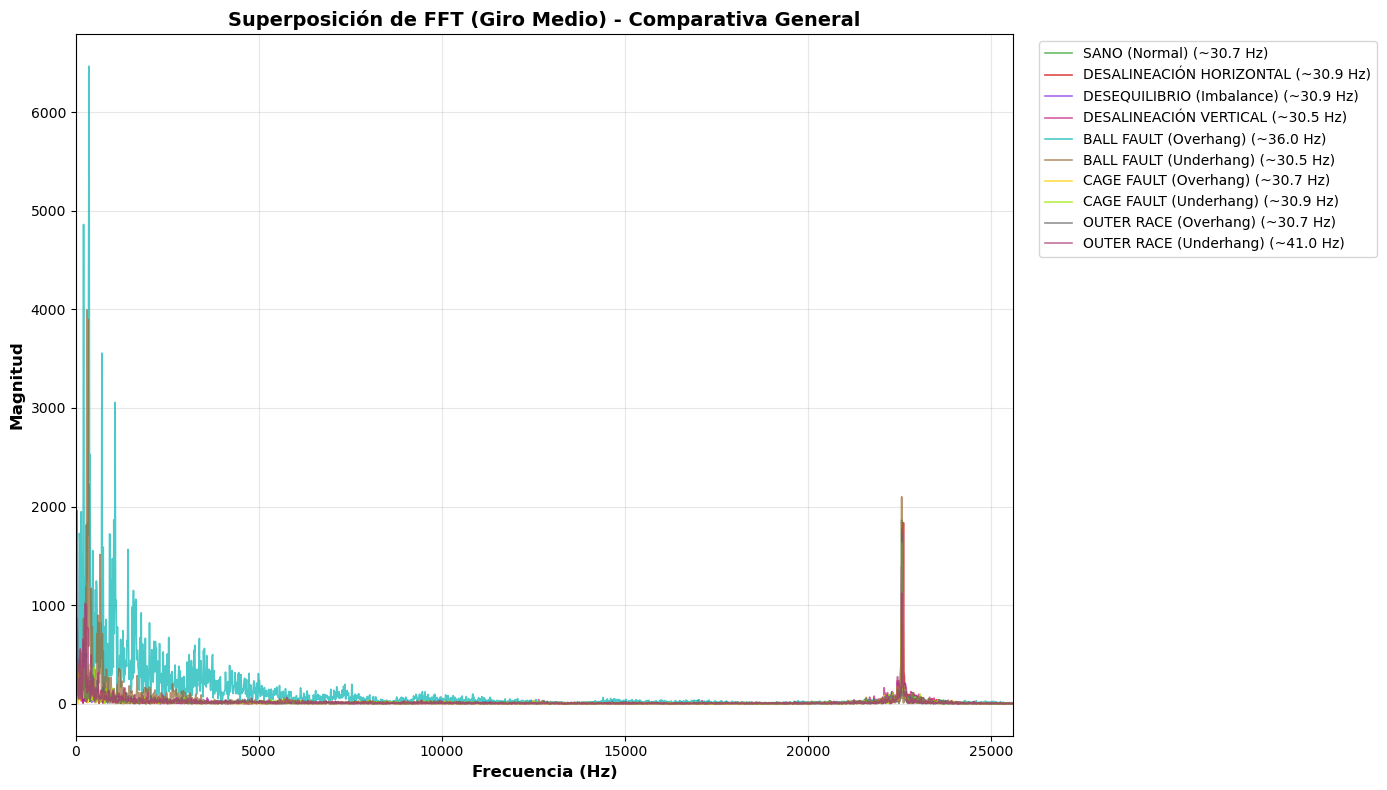

In [46]:
plt.figure(figsize=(14, 8))

for nombre, condicion, color in categorias:
    df_filtrado = df_all[condicion]
    
    if df_filtrado.empty:
        continue
        
    archivos = df_filtrado['source_file'].unique()
    
    velocidades = [extraer_velocidad(arc) for arc in archivos]
    vel_min = min(velocidades)
    vel_max = max(velocidades)
    vel_objetivo = (vel_min + vel_max) / 2.0
    
    archivo_sel = min(archivos, key=lambda x: abs(extraer_velocidad(x) - vel_objetivo))
    vel_hz = extraer_velocidad(archivo_sel)
    
    signal_cruda = df_filtrado[df_filtrado["source_file"] == archivo_sel]["acc_under_axial"].values[:n_fft]
    rfft_mag = np.abs(np.fft.rfft(signal_cruda))
    rfreqs = np.fft.rfftfreq(len(signal_cruda), 1/fs)
    rfft_mag[0] = 0 
    
    plt.plot(rfreqs, rfft_mag, color=color, linewidth=1.2, alpha=0.7, label=f"{nombre} (~{vel_hz:.1f} Hz)")

plt.title("Superposición de FFT (Giro Medio) - Comparativa General", fontweight="bold", fontsize=14)
plt.xlabel("Frecuencia (Hz)", fontsize=12, fontweight="bold")
plt.ylabel("Magnitud", fontsize=12, fontweight="bold")
plt.xlim(0, 25600)

plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## 8. Filtrado digital

Se utiliza un filtro Butterworth paso bajo de orden 4.

El filtrado se hace por archivo para:
- respetar la continuidad temporal,
- evitar mezclar señales distintas,
- reducir artefactos entre archivos concatenados.

In [47]:
def lowpass_filter(signal, cutoff=5000, fs=FS, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype="low")
    return filtfilt(b, a, signal)

In [48]:
tacho_signal = demo["tachometer"].values
umbral = (tacho_signal.max() + tacho_signal.min()) / 2
pulsos = ((tacho_signal[:-1] < umbral) & (tacho_signal[1:] >= umbral)).sum()

duracion = len(tacho_signal) / 51200
frecuencia_giro_hz = pulsos / duracion
rpm = frecuencia_giro_hz * 60

print(f"Frecuencia de giro medida: {round(frecuencia_giro_hz, 2)} Hz")
print(f"Velocidad del motor: {round(rpm, 0)} RPM")

Frecuencia de giro medida: 12.29 Hz
Velocidad del motor: 737.0 RPM


El uso de 5 Hz como frecuencia de corte inferior es la elección matemáticamente y físicamente correcta por tres motivos clave:

Limpia el ruido no mecánico: Elimina la deriva del sensor (DC offset), el ruido térmico y las vibraciones estructurales lentas que ocurren cerca de los 0 Hz, logrando que la señal oscile perfectamente centrada.

Protege la frecuencia fundamental (1X): Al haber comprobado que el motor gira a 12.29 Hz, usar un límite más alto (como 20 Hz) borraría la propia rotación del eje. Esto volvería al modelo "ciego" ante averías críticas como el desequilibrio o la desalineación, que vibran exactamente a esa velocidad.

Respeta la curva de atenuación: Los filtros Butterworth no son un muro que corta en seco; tienen una curva de caída suave. Al fijar el límite en 5 Hz, garantizamos que cuando la señal alcance los críticos 12.29 Hz, el filtro ya estará totalmente abierto en su "zona plana", dejando pasar la energía del impacto al 100%.

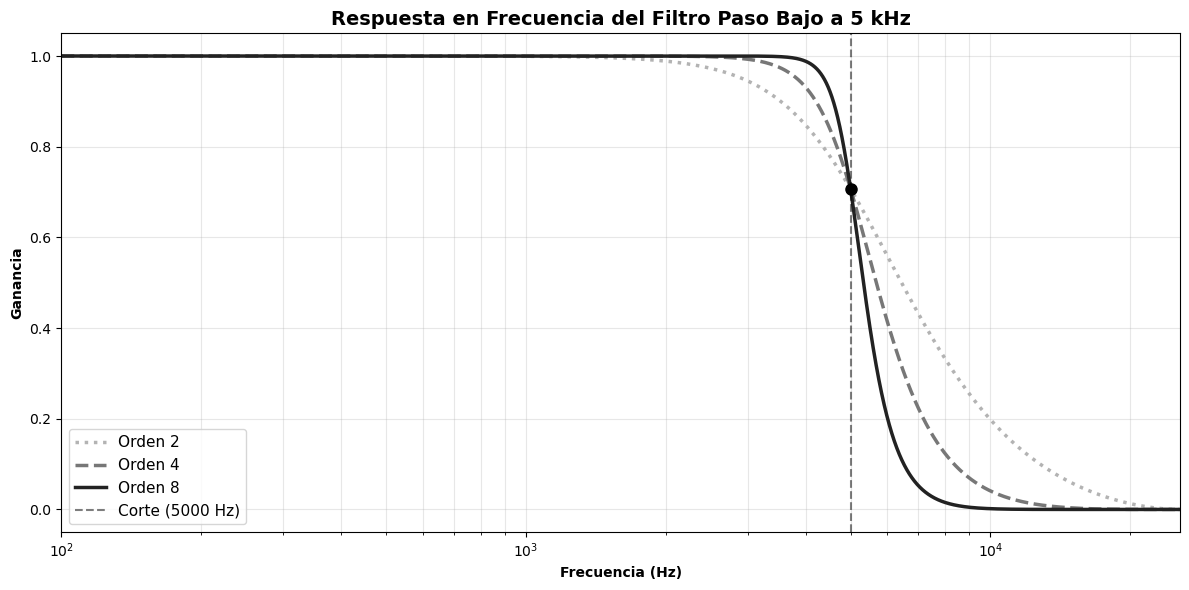

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfreqz

fs = 51200
cutoff = 5000 

w = np.logspace(np.log10(100), np.log10(25600), 8000)

plt.figure(figsize=(12, 6))

ordenes = [2, 4, 8]
colores = ["#b3b3b3", "#777777", "#222222"] 
estilos = [":", "--", "-"]

for order, color, estilo in zip(ordenes, colores, estilos):
    sos = butter(order, cutoff, btype='low', fs=fs, output='sos')
    
    w_hz, h = sosfreqz(sos, worN=w, fs=fs)
    plt.plot(w_hz, np.abs(h), color=color, linestyle=estilo, linewidth=2.5, label=f"Orden {order}")

plt.plot(cutoff, 0.5 * np.sqrt(2), 'ko', markersize=8) 
plt.axvline(cutoff, color='k', linestyle='--', alpha=0.5, label=f'Corte ({cutoff} Hz)')

plt.title("Respuesta en Frecuencia del Filtro Paso Bajo a 5 kHz", fontweight="bold", fontsize=14)
plt.xlabel("Frecuencia (Hz)", fontweight="bold")
plt.ylabel("Ganancia", fontweight="bold")

plt.xscale('log')
plt.xlim(100, 25600) 
plt.ylim(-0.05, 1.05)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(loc="lower left", fontsize=11) 
plt.tight_layout()

plt.show()

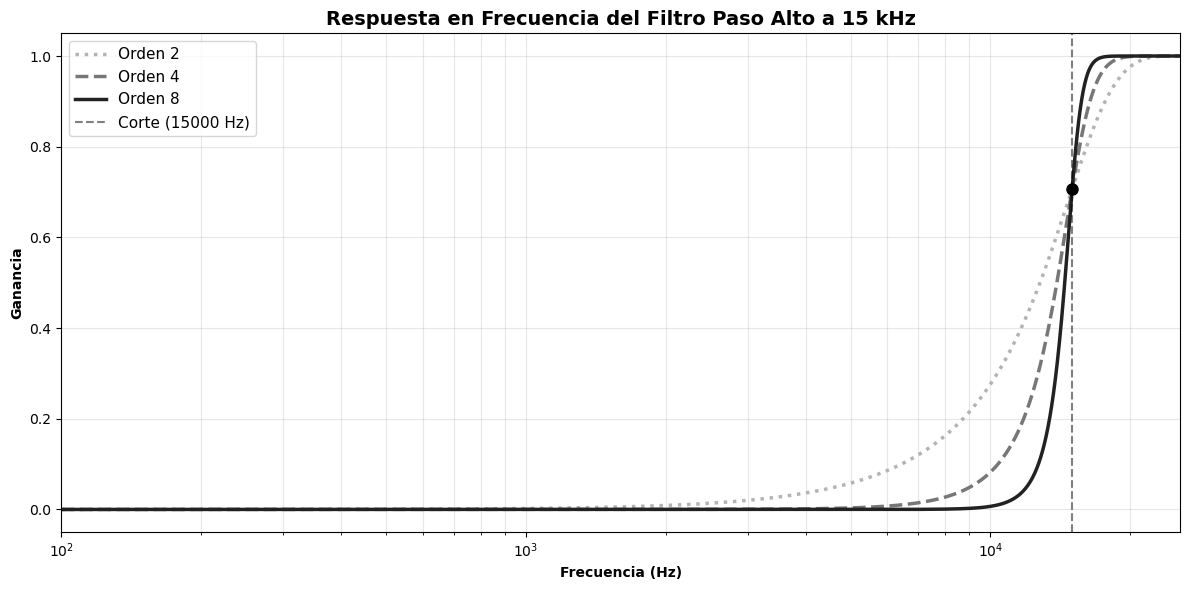

In [50]:
def apply_highpass_filter(data, cutoff=15000, fs=51200, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, data)

categorias = [
    ("SANO", df_all['label'] == 'normal', "#2ca02c"), 
    ("DESAL. HORIZ.", df_all['label'] == 'horizontal-misalignment', "#cc0000"), 
    ("DESEQUILIBRIO", df_all['label'] == 'imbalance', "#8a2be2"), 
    ("DESAL. VERT.", df_all['label'] == 'vertical-misalignment', "#c51b7d"), 
    ("BALL (Over)", (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#00b3b3"),
    ("BALL (Under)", (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#996633"), 
    ("CAGE (Over)", (df_all['label'] == 'cage_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#ffcc00"), 
    ("CAGE (Under)", (df_all['label'] == 'cage_fault') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#99e600"), 
    ("OUTER (Over)", (df_all['label'] == 'outer_race') & (df_all['source_file'].str.contains('overhang', case=False, na=False)), "#666666"), 
    ("OUTER (Under)", (df_all['label'] == 'outer_race') & (df_all['source_file'].str.contains('underhang', case=False, na=False)), "#ac3973")  
]

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfreqz

fs = 51200
cutoff = 15000

w = np.logspace(np.log10(100), np.log10(25600), 8000)

plt.figure(figsize=(12, 6))

ordenes = [2, 4, 8]
colores = ["#b3b3b3", "#777777", "#222222"] 
estilos = [":", "--", "-"]

for order, color, estilo in zip(ordenes, colores, estilos):
    sos = butter(order, cutoff, btype='high', fs=fs, output='sos')
    
    w_hz, h = sosfreqz(sos, worN=w, fs=fs)
    plt.plot(w_hz, np.abs(h), color=color, linestyle=estilo, linewidth=2.5, label=f"Orden {order}")

plt.plot(cutoff, 0.5 * np.sqrt(2), 'ko', markersize=8) 
plt.axvline(cutoff, color='k', linestyle='--', alpha=0.5, label=f'Corte ({cutoff} Hz)')

plt.title("Respuesta en Frecuencia del Filtro Paso Alto a 15 kHz", fontweight="bold", fontsize=14)
plt.xlabel("Frecuencia (Hz)", fontweight="bold")
plt.ylabel("Ganancia", fontweight="bold")

plt.xscale('log')
plt.xlim(100, 25600) 
plt.ylim(-0.05, 1.05)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(loc="upper left", fontsize=11)
plt.tight_layout()

plt.show()
    

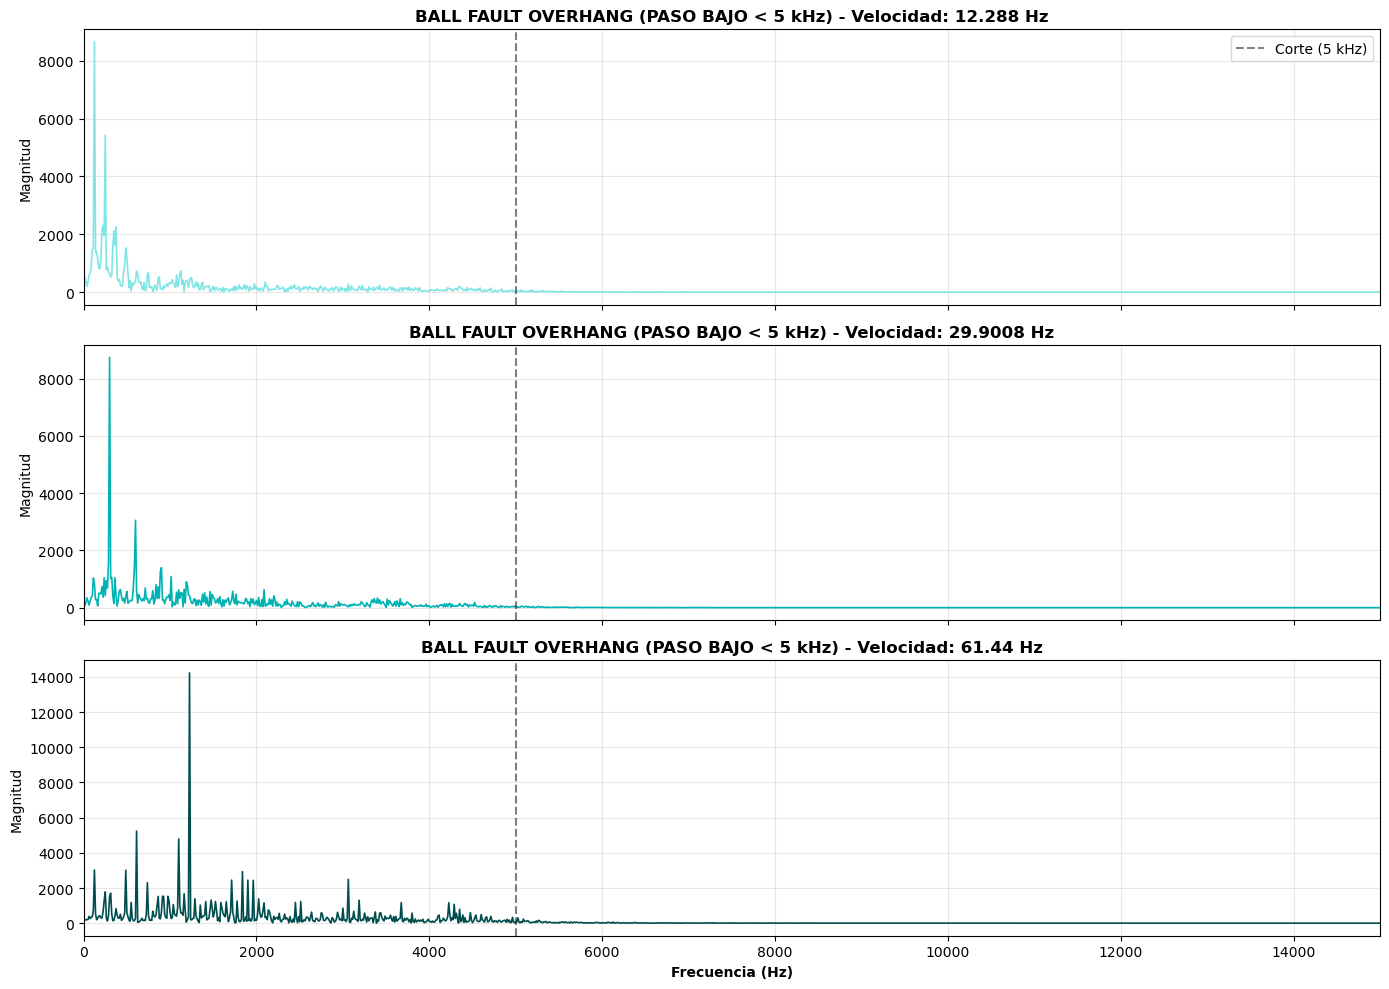

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

# Aislar el caso
condicion = (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False))
df_ball_over = df_all[condicion]

archivos = df_ball_over['source_file'].unique()
archivos_ordenados = sorted(archivos, key=extraer_velocidad)

archivos_sel = [
    archivos_ordenados[0], 
    archivos_ordenados[len(archivos_ordenados)//2], 
    archivos_ordenados[-1]
]


fs = 51200
cutoff = 5000 
order = 4
n_fft = 4096

# <--- CAMBIADO A 'low'
sos = butter(order, cutoff, btype='low', fs=fs, output='sos')

colores = ["#80e5e5", "#00b3b3", "#004d4d"] 

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, archivo in enumerate(archivos_sel):
    signal_cruda = df_ball_over[df_ball_over["source_file"] == archivo]["acc_under_axial"].values[:n_fft]
    
    # Aplicar el filtro con la función estable SOS
    signal_filtrada = sosfiltfilt(sos, signal_cruda)
    
    # Calcular FFT
    rfft_mag = np.abs(np.fft.rfft(signal_filtrada))
    rfreqs = np.fft.rfftfreq(len(signal_filtrada), 1/fs)
    rfft_mag[0] = 0
    
    vel_hz = extraer_velocidad(archivo)
    
    axs[i].plot(rfreqs, rfft_mag, color=colores[i], linewidth=1.2)
    axs[i].axvline(cutoff, color='k', linestyle='--', alpha=0.5, label="Corte (5 kHz)")
    axs[i].set_title(f"BALL FAULT OVERHANG (PASO BAJO < 5 kHz) - Velocidad: {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Magnitud")
    axs[i].grid(True, alpha=0.3)
    
    if i == 0:
        axs[i].legend(loc="upper right")

# He reducido un poco el límite X a 15000 para que se vea mejor la zona de bajas frecuencias
plt.xlim(0, 15000) 
axs[2].set_xlabel("Frecuencia (Hz)", fontweight="bold")
plt.tight_layout()
plt.show()

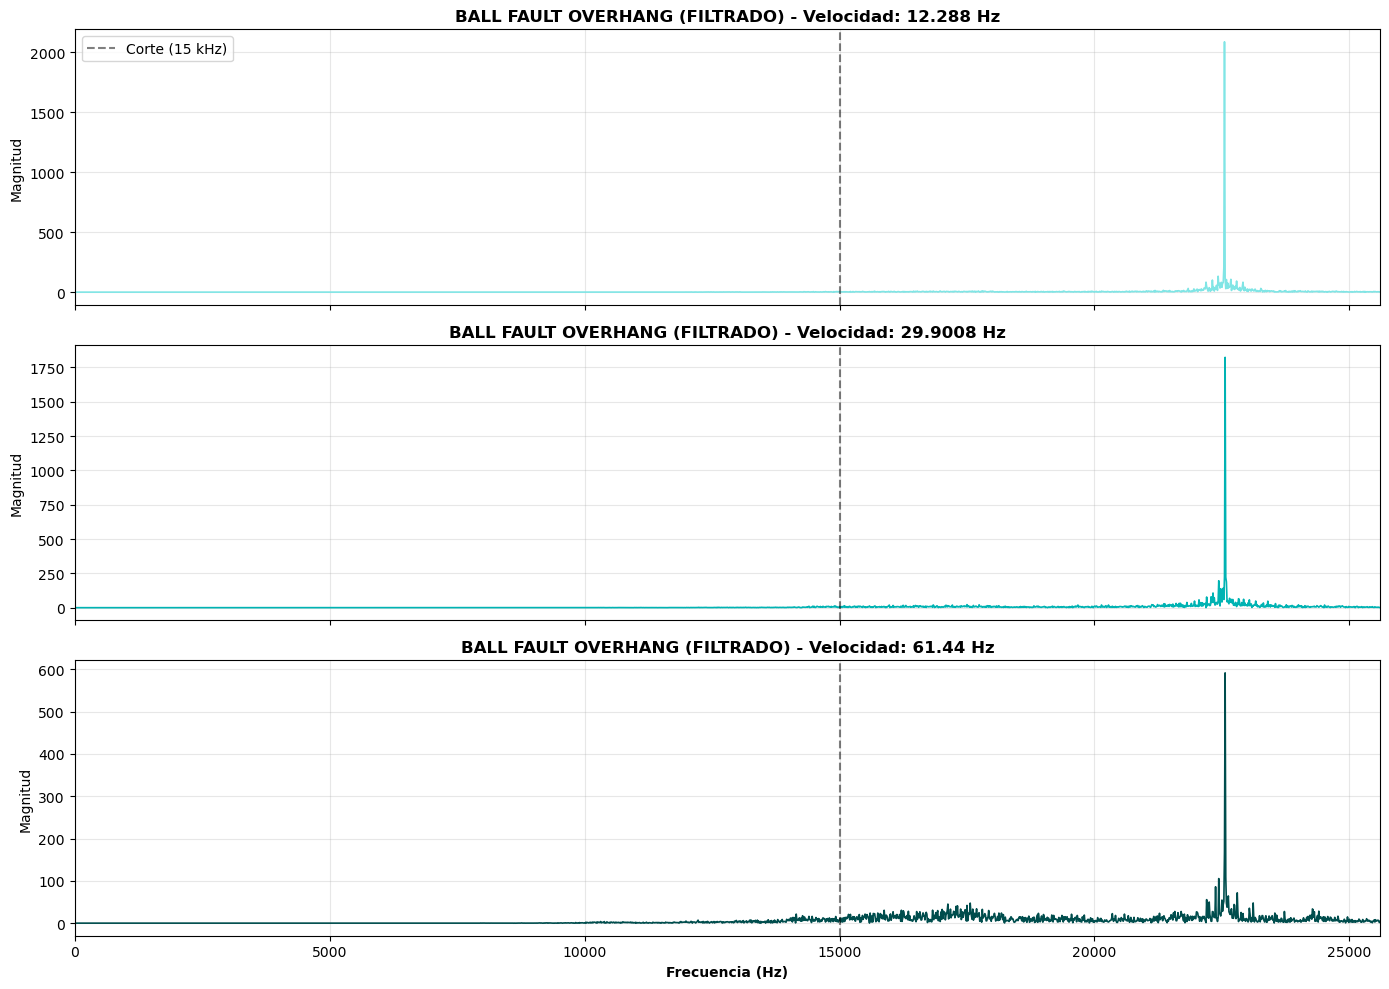

In [52]:
condicion = (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False))
df_ball_over = df_all[condicion]

archivos = df_ball_over['source_file'].unique()
archivos_ordenados = sorted(archivos, key=extraer_velocidad)

archivos_sel = [
    archivos_ordenados[0], 
    archivos_ordenados[len(archivos_ordenados)//2], 
    archivos_ordenados[-1]
]

fs = 51200
cutoff = 15000
order = 4
n_fft = 4096

sos = butter(order, cutoff, btype='high', fs=fs, output='sos')

colores = ["#80e5e5", "#00b3b3", "#004d4d"] 

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, archivo in enumerate(archivos_sel):
    signal_cruda = df_ball_over[df_ball_over["source_file"] == archivo]["acc_under_axial"].values[:n_fft]
    
    signal_filtrada = sosfiltfilt(sos, signal_cruda)
    
    rfft_mag = np.abs(np.fft.rfft(signal_filtrada))
    rfreqs = np.fft.rfftfreq(len(signal_filtrada), 1/fs)
    rfft_mag[0] = 0
    
    vel_hz = extraer_velocidad(archivo)
    
    axs[i].plot(rfreqs, rfft_mag, color=colores[i], linewidth=1.2)
    axs[i].axvline(cutoff, color='k', linestyle='--', alpha=0.5, label="Corte (15 kHz)")
    axs[i].set_title(f"BALL FAULT OVERHANG (FILTRADO) - Velocidad: {vel_hz} Hz", fontweight="bold")
    axs[i].set_ylabel("Magnitud")
    axs[i].grid(True, alpha=0.3)
    
    if i == 0:
        axs[i].legend(loc="upper left")

plt.xlim(0, 25600)
axs[2].set_xlabel("Frecuencia (Hz)", fontweight="bold")
plt.tight_layout()
plt.show()

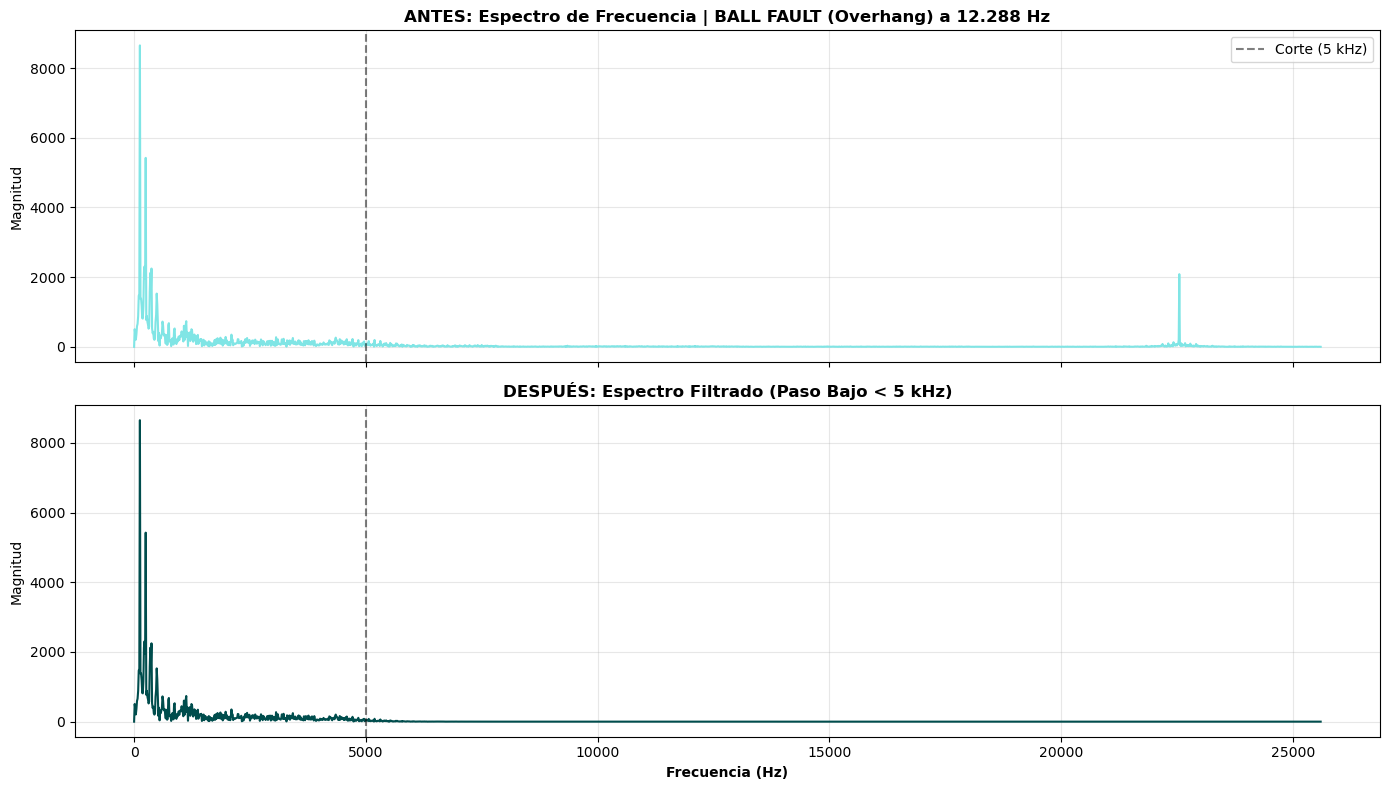

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Aseguramos que usamos tu función de Paso Bajo
def lowpass_filter(signal, cutoff=5000, fs=51200, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype="low")
    return filtfilt(b, a, signal)

# 1. Aislamos el caso crítico
condicion = (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False))
df_ball_over = df_all[condicion]

archivos_ordenados = sorted(df_ball_over['source_file'].unique(), key=extraer_velocidad)
archivo_sel = archivos_ordenados[0] 
vel_hz = extraer_velocidad(archivo_sel)

# 2. Extraemos la señal y aplicamos el PASO BAJO
fs = 51200
n_fft = 4096
signal_cruda = df_ball_over[df_ball_over["source_file"] == archivo_sel]["acc_under_axial"].values[:n_fft]

signal_filtrada = lowpass_filter(signal_cruda, cutoff=5000, fs=fs)

# 3. Calculamos la FFT para el Antes y el Después
rfreqs = np.fft.rfftfreq(n_fft, 1/fs)

fft_cruda = np.abs(np.fft.rfft(signal_cruda))
fft_filt = np.abs(np.fft.rfft(signal_filtrada))

# Eliminamos la continua (0 Hz)
fft_cruda[0] = 0
fft_filt[0] = 0

# ==========================================
# 4. VISUALIZACIÓN DEL ANTES Y DESPUÉS (PASO BAJO)
# ==========================================
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Arriba: ANTES (FFT Señal Cruda)
axs[0].plot(rfreqs, fft_cruda, color="#80e5e5", linewidth=1.5)
axs[0].axvline(5000, color='k', linestyle='--', alpha=0.5, label="Corte (5 kHz)")
axs[0].set_title(f"ANTES: Espectro de Frecuencia | BALL FAULT (Overhang) a {vel_hz} Hz", fontweight="bold")
axs[0].set_ylabel("Magnitud")
axs[0].legend(loc="upper right")
axs[0].grid(True, alpha=0.3)

# Abajo: DESPUÉS (FFT Señal Filtrada)
axs[1].plot(rfreqs, fft_filt, color="#004d4d", linewidth=1.5)
axs[1].axvline(5000, color='k', linestyle='--', alpha=0.5)
axs[1].set_title("DESPUÉS: Espectro Filtrado (Paso Bajo < 5 kHz)", fontweight="bold")
axs[1].set_xlabel("Frecuencia (Hz)", fontweight="bold")
axs[1].set_ylabel("Magnitud")
axs[1].grid(True, alpha=0.3)

# Limitamos a 15 kHz para centrar la vista en el rango de paso bajo
plt.tight_layout()
plt.show()

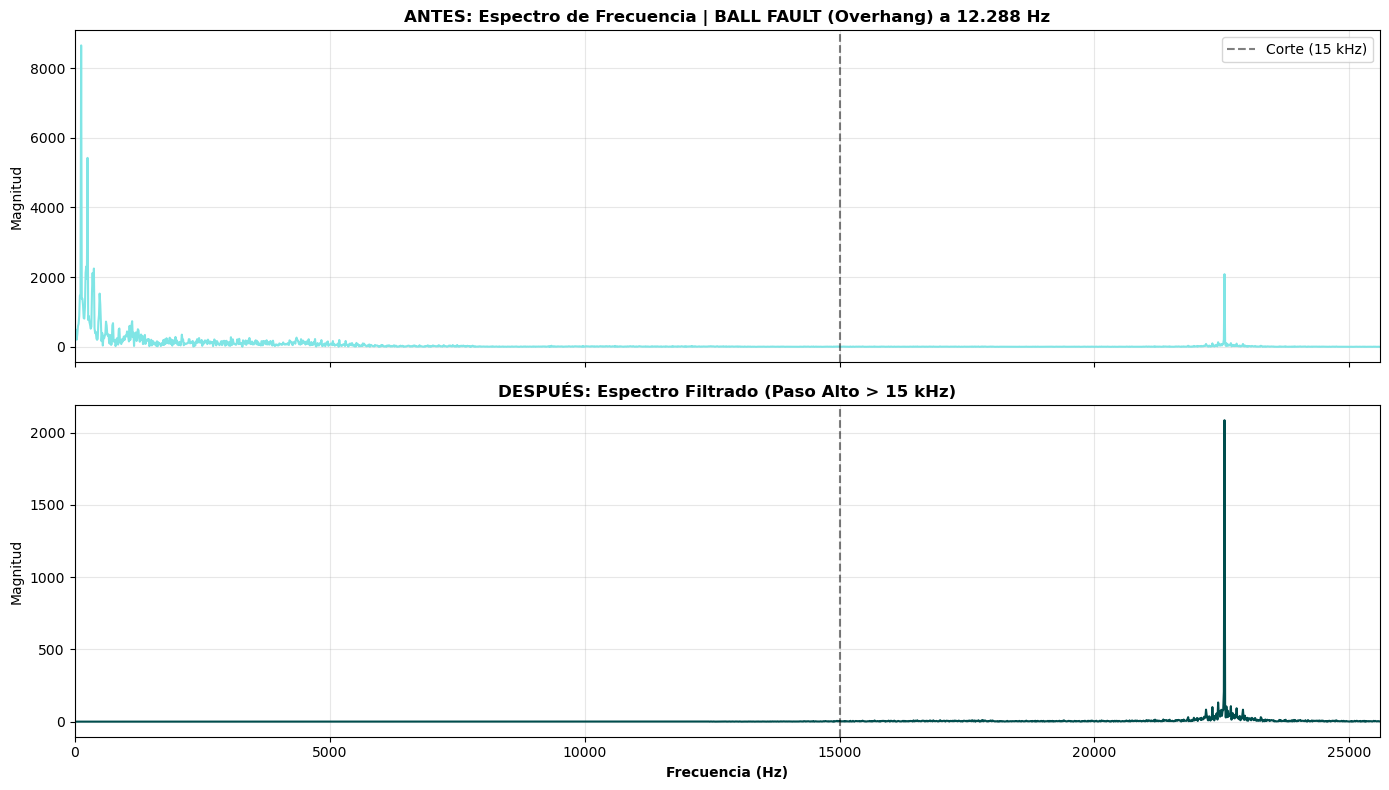

In [54]:
condicion = (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False))
df_ball_over = df_all[condicion]

archivos_ordenados = sorted(df_ball_over['source_file'].unique(), key=extraer_velocidad)
archivo_sel = archivos_ordenados[0] 
vel_hz = extraer_velocidad(archivo_sel)

fs = 51200
n_fft = 4096
signal_cruda = df_ball_over[df_ball_over["source_file"] == archivo_sel]["acc_under_axial"].values[:n_fft]
signal_filtrada = apply_highpass_filter(signal_cruda, cutoff=15000, fs=fs)

rfreqs = np.fft.rfftfreq(n_fft, 1/fs)

fft_cruda = np.abs(np.fft.rfft(signal_cruda))
fft_filt = np.abs(np.fft.rfft(signal_filtrada))

fft_cruda[0] = 0
fft_filt[0] = 0

fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axs[0].plot(rfreqs, fft_cruda, color="#80e5e5", linewidth=1.5)
axs[0].axvline(15000, color='k', linestyle='--', alpha=0.5, label="Corte (15 kHz)")
axs[0].set_title(f"ANTES: Espectro de Frecuencia | BALL FAULT (Overhang) a {vel_hz} Hz", fontweight="bold")
axs[0].set_ylabel("Magnitud")
axs[0].legend(loc="upper right")
axs[0].grid(True, alpha=0.3)

axs[1].plot(rfreqs, fft_filt, color="#004d4d", linewidth=1.5)
axs[1].axvline(15000, color='k', linestyle='--', alpha=0.5)
axs[1].set_title("DESPUÉS: Espectro Filtrado (Paso Alto > 15 kHz)", fontweight="bold")
axs[1].set_xlabel("Frecuencia (Hz)", fontweight="bold")
axs[1].set_ylabel("Magnitud")
axs[1].grid(True, alpha=0.3)

plt.xlim(0, 25600)
plt.tight_layout()
plt.show()

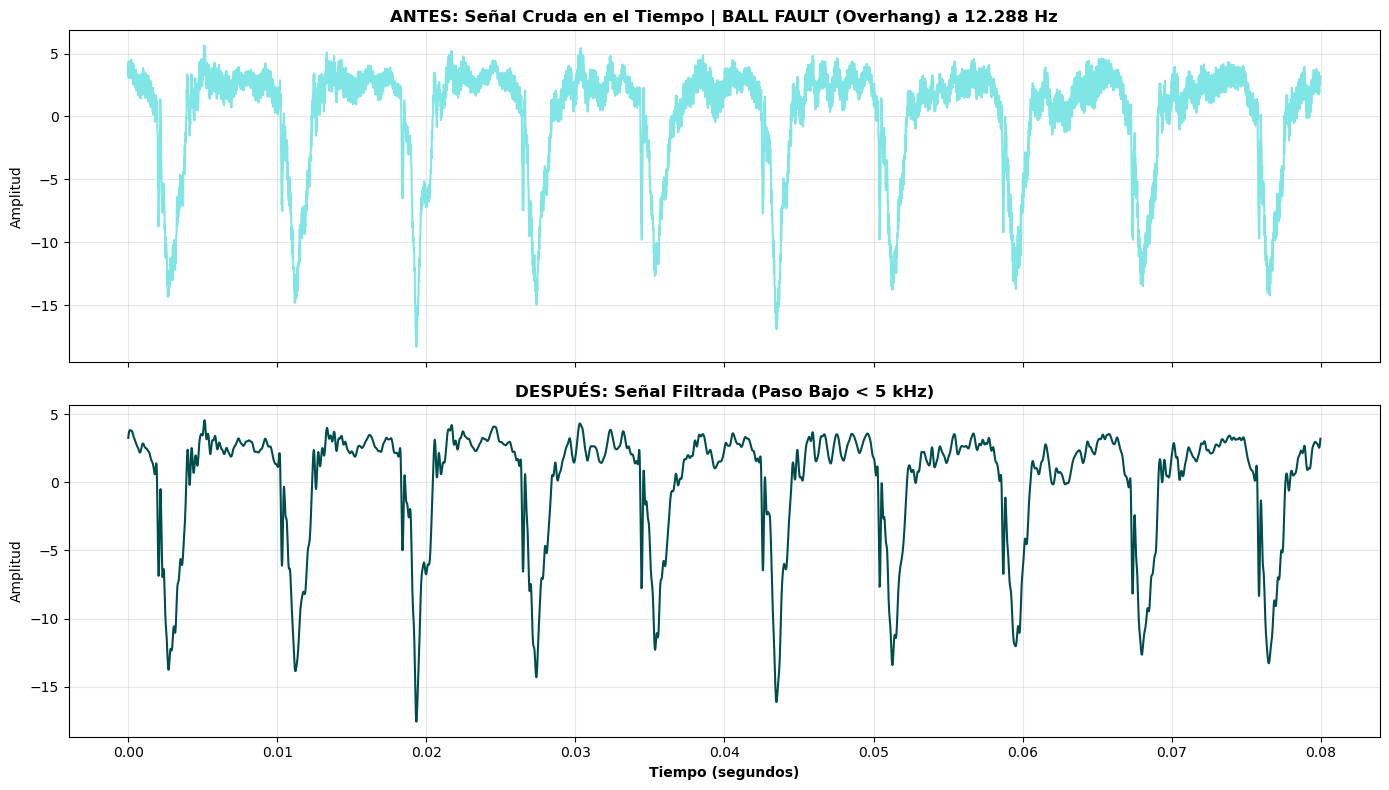

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Aseguramos la función del Paso Bajo
def lowpass_filter(signal, cutoff=5000, fs=51200, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype="low")
    return filtfilt(b, a, signal)

# 1. Aislamos el caso crítico: ball_fault, overhang
condicion = (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False))
df_ball_over = df_all[condicion]

archivos_ordenados = sorted(df_ball_over['source_file'].unique(), key=extraer_velocidad)
archivo_sel = archivos_ordenados[0] 
vel_hz = extraer_velocidad(archivo_sel)

# 2. Extraemos la señal
fs = 51200
n_muestras = 4096 
signal_cruda = df_ball_over[df_ball_over["source_file"] == archivo_sel]["acc_under_axial"].values[:n_muestras]

# APLICAMOS EL FILTRO PASO BAJO
signal_filtrada = lowpass_filter(signal_cruda, cutoff=5000, fs=fs)

# Creamos el eje X en segundos
tiempo = np.arange(len(signal_cruda)) / fs

# ==========================================
# 3. VISUALIZACIÓN DEL ANTES Y DESPUÉS (TIEMPO)
# ==========================================
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Arriba: ANTES (Señal Cruda)
axs[0].plot(tiempo, signal_cruda, color="#80e5e5", linewidth=1.5) 
axs[0].set_title(f"ANTES: Señal Cruda en el Tiempo | BALL FAULT (Overhang) a {vel_hz} Hz", fontweight="bold")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True, alpha=0.3)

# Abajo: DESPUÉS (Señal Filtrada por Paso Bajo)
axs[1].plot(tiempo, signal_filtrada, color="#004d4d", linewidth=1.5) 
axs[1].set_title("DESPUÉS: Señal Filtrada (Paso Bajo < 5 kHz)", fontweight="bold")
axs[1].set_xlabel("Tiempo (segundos)", fontweight="bold")
axs[1].set_ylabel("Amplitud")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

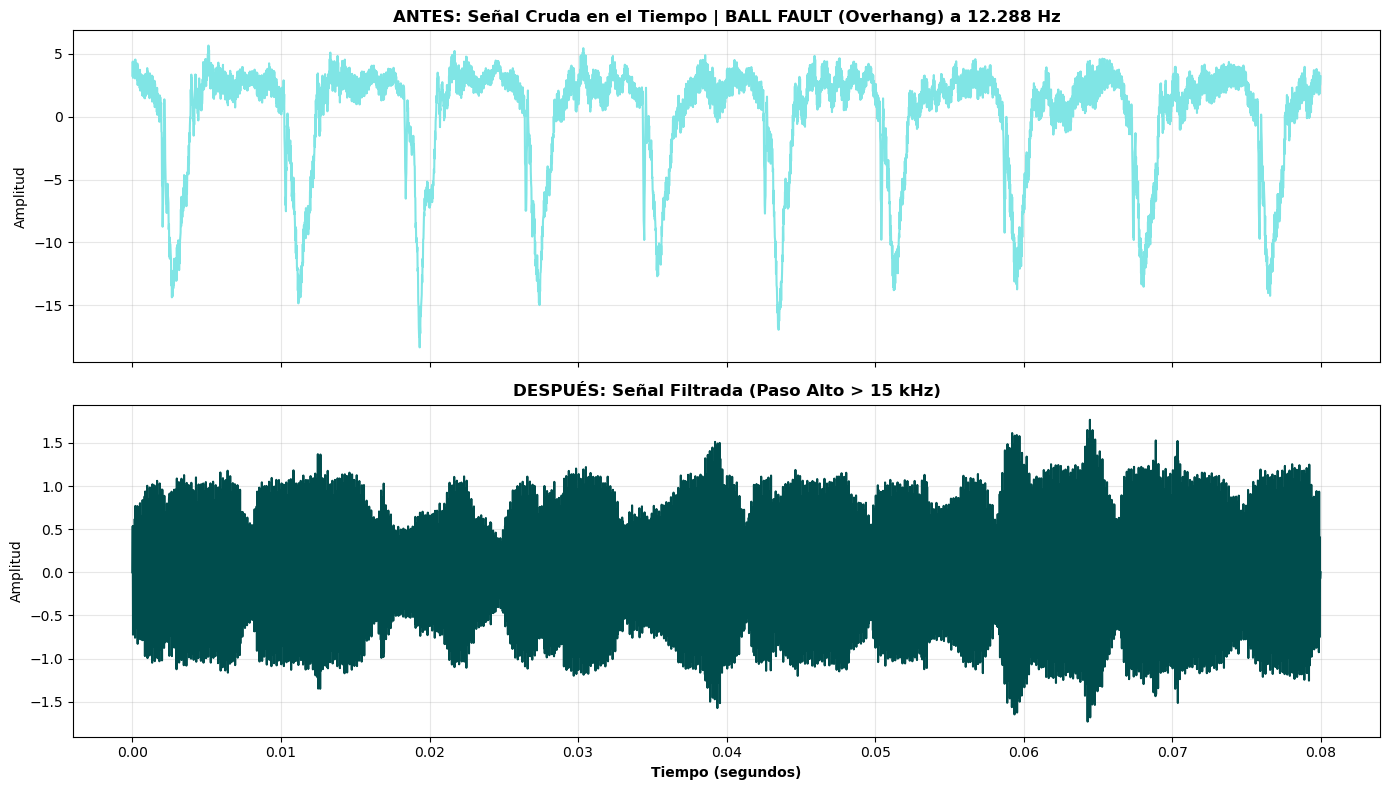

In [56]:
condicion = (df_all['label'] == 'ball_fault') & (df_all['source_file'].str.contains('overhang', case=False, na=False))
df_ball_over = df_all[condicion]

archivos_ordenados = sorted(df_ball_over['source_file'].unique(), key=extraer_velocidad)
archivo_sel = archivos_ordenados[0] 
vel_hz = extraer_velocidad(archivo_sel)

fs = 51200
n_muestras = 4096 
signal_cruda = df_ball_over[df_ball_over["source_file"] == archivo_sel]["acc_under_axial"].values[:n_muestras]

signal_filtrada = apply_highpass_filter(signal_cruda, cutoff=15000, fs=fs)

tiempo = np.arange(len(signal_cruda)) / fs

fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axs[0].plot(tiempo, signal_cruda, color="#80e5e5", linewidth=1.5) 
axs[0].set_title(f"ANTES: Señal Cruda en el Tiempo | BALL FAULT (Overhang) a {vel_hz} Hz", fontweight="bold")
axs[0].set_ylabel("Amplitud")
axs[0].grid(True, alpha=0.3)

axs[1].plot(tiempo, signal_filtrada, color="#004d4d", linewidth=1.5) 
axs[1].set_title("DESPUÉS: Señal Filtrada (Paso Alto > 15 kHz)", fontweight="bold")
axs[1].set_xlabel("Tiempo (segundos)", fontweight="bold")
axs[1].set_ylabel("Amplitud")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Extracción de características



In [ ]:
FS = 51200
WINDOW_SIZE = 4096
STEP_SIZE = 2048
signal_cols = ["acc_under_axial", "acc_under_radiale", "acc_under_tangencial"]

In [ ]:
def extract_features_from_signal(signal, fs=FS):
    feats = {}

    feats["mean"] = np.mean(signal)
    feats["std"] = np.std(signal)
    feats["var"] = np.var(signal)
    feats["max"] = np.max(signal)
    feats["min"] = np.min(signal)
    feats["ptp"] = np.ptp(signal)
    feats["rms"] = np.sqrt(np.mean(signal**2))
    feats["kurtosis"] = kurtosis(signal)
    feats["skewness"] = skew(signal)

    rms = feats["rms"]
    feats["crest_factor"] = np.max(np.abs(signal)) / rms if rms != 0 else 0

    spectrum = np.abs(rfft(signal))
    freqs = rfftfreq(len(signal), d=1/fs)

    feats["fft_mean"] = np.mean(spectrum)
    feats["fft_std"] = np.std(spectrum)
    feats["fft_max"] = np.max(spectrum)
    feats["spectral_energy"] = np.sum(spectrum**2)

    top_indices = np.argsort(spectrum)[-3:][::-1]
    
    feats["dominant_freq_1"] = freqs[top_indices[0]]
    feats["dominant_freq_2"] = freqs[top_indices[1]]
    feats["dominant_freq_3"] = freqs[top_indices[2]]

    return feats

In [ ]:
def process_one_file(group, signal_cols, fs=FS): # Eliminamos los parámetros de window_size y step_size
    group = group.copy().reset_index(drop=True)

    mount_position = str(group["mount_position"].iloc[0])
    label = str(group["label"].iloc[0])
    fault_level = str(group["fault_level"].iloc[0])
    source_file = str(group["source_file"].iloc[0])

    signals_lp = {} 
    signals_hp = {} 
    
    for col in signal_cols:
        cruda = group[col].to_numpy(dtype=np.float32)
        
        # BANCO DE FILTROS SOBRE LA SEÑAL COMPLETA
        signals_lp[col] = lowpass_filter(cruda, cutoff=5000, fs=fs, order=4)
        signals_hp[col] = apply_highpass_filter(cruda, cutoff=15000, fs=fs, order=4)

    # Ya no hay troceado. Preparamos una ÚNICA fila para este archivo entero
    row = {
        "mount_position": mount_position,
        "label": label,
        "fault_level": fault_level,
        "source_file": source_file
      
    }

    # EXTRAEMOS CARACTERÍSTICAS DE LA SEÑAL ENTERA
    for col in signal_cols:
        # --- Camino de Bajas Frecuencias (lp) ---
        feats_lp = extract_features_from_signal(signals_lp[col], fs=fs)
        for key, value in feats_lp.items():
            row[f"{col}_lp_{key}"] = value 
            
        
        feats_hp = extract_features_from_signal(signals_hp[col], fs=fs)
        for key, value in feats_hp.items():
            row[f"{col}_hp_{key}"] = value 

    
    return [row]

## 10. Pipeline completo por archivo

Se recorre cada archivo del dataset y se generan las features por ventana.

In [75]:
from pathlib import Path
from tqdm import tqdm
import pandas as pd

features_list = []

# El bucle ahora procesará 168 archivos y sacará exactamente 168 filas
for source_file, group in tqdm(df_all.groupby("source_file"), desc="Procesando señales completas (LP + HP)"):
    rows = process_one_file(
        group,
        signal_cols=signal_cols,
        fs=FS
        # Eliminados window_size y step_size
    )
    features_list.extend(rows)

df_features = pd.DataFrame(features_list)
print("Shape df_features:", df_features.shape) # Debería salirte (168, N_columnas)

def detallar_etiqueta(row):
    label_original = str(row['label']).replace('-misalignment', '_misalignment')
    archivo = str(row['source_file']).lower()
    
    if label_original in ['ball_fault', 'cage_fault', 'outer_race']:
        if 'overhang' in archivo:
            return f"{label_original}_overhang"
        elif 'underhang' in archivo:
            return f"{label_original}_underhang"
            
    return label_original

df_features["detailed_label"] = df_features.apply(detallar_etiqueta, axis=1)




Procesando señales completas (LP + HP): 100%|██████████| 168/168 [00:29<00:00,  5.66it/s]


Shape df_features: (168, 106)


## 11. Guardado del dataset final
Se guarda el dataframe de características para el notebook de modelado.

In [88]:
from pathlib import Path

# Buscar automáticamente la raíz del proyecto
BASE_DIR = Path.cwd()

while BASE_DIR.name != "Verde_Oscuro_RETO11":
    BASE_DIR = BASE_DIR.parent

print("BASE_DIR detectado:", BASE_DIR)

# Ruta destino
output_dir = (
    BASE_DIR
    / "Datos"
    / "Transformados"
    / "Industria"
)

output_dir.mkdir(parents=True, exist_ok=True)
ruta_guardado = output_dir / "df_features_reducido.csv"
df_features.to_csv(ruta_guardado, index=False)



BASE_DIR detectado: c:\Bdata3\Verde_Oscuro_RETO11


In [90]:
df_features_completo=pd.read_csv('.\Datos\Transformados\Industria\df_features_reducido.csv')

In [92]:
df_features_completo.head()

,mount_position,label,fault_level,source_file,acc_under_axial_lp_mean,acc_under_axial_lp_std,acc_under_axial_lp_var,acc_under_axial_lp_max,acc_under_axial_lp_min,acc_under_axial_lp_ptp,acc_under_axial_lp_rms,acc_under_axial_lp_kurtosis,acc_under_axial_lp_skewness,acc_under_axial_lp_crest_factor,acc_under_axial_lp_fft_mean,acc_under_axial_lp_fft_std,acc_under_axial_lp_fft_max,acc_under_axial_lp_spectral_energy,acc_under_axial_lp_dominant_freq_1,acc_under_axial_lp_dominant_freq_2,acc_under_axial_lp_dominant_freq_3,acc_under_axial_hp_mean,acc_under_axial_hp_std,acc_under_axial_hp_var,acc_under_axial_hp_max,acc_under_axial_hp_min,acc_under_axial_hp_ptp,acc_under_axial_hp_rms,acc_under_axial_hp_kurtosis,acc_under_axial_hp_skewness,acc_under_axial_hp_crest_factor,acc_under_axial_hp_fft_mean,acc_under_axial_hp_fft_std,acc_under_axial_hp_fft_max,acc_under_axial_hp_spectral_energy,acc_under_axial_hp_dominant_freq_1,acc_under_axial_hp_dominant_freq_2,acc_under_axial_hp_dominant_freq_3,acc_under_radiale_lp_mean,acc_under_radiale_lp_std,acc_under_radiale_lp_var,acc_under_radiale_lp_max,acc_under_radiale_lp_min,acc_under_radiale_lp_ptp,acc_under_radiale_lp_rms,acc_under_radiale_lp_kurtosis,acc_under_radiale_lp_skewness,acc_under_radiale_lp_crest_factor,acc_under_radiale_lp_fft_mean,acc_under_radiale_lp_fft_std,acc_under_radiale_lp_fft_max,acc_under_radiale_lp_spectral_energy,acc_under_radiale_lp_dominant_freq_1,acc_under_radiale_lp_dominant_freq_2,acc_under_radiale_lp_dominant_freq_3,acc_under_radiale_hp_mean,acc_under_radiale_hp_std,acc_under_radiale_hp_var,acc_under_radiale_hp_max,acc_under_radiale_hp_min,acc_under_radiale_hp_ptp,acc_under_radiale_hp_rms,acc_under_radiale_hp_kurtosis,acc_under_radiale_hp_skewness,acc_under_radiale_hp_crest_factor,acc_under_radiale_hp_fft_mean,acc_under_radiale_hp_fft_std,acc_under_radiale_hp_fft_max,acc_under_radiale_hp_spectral_energy,acc_under_radiale_hp_dominant_freq_1,acc_under_radiale_hp_dominant_freq_2,acc_under_radiale_hp_dominant_freq_3,acc_under_tangencial_lp_mean,acc_under_tangencial_lp_std,acc_under_tangencial_lp_var,acc_under_tangencial_lp_max,acc_under_tangencial_lp_min,acc_under_tangencial_lp_ptp,acc_under_tangencial_lp_rms,acc_under_tangencial_lp_kurtosis,acc_under_tangencial_lp_skewness,acc_under_tangencial_lp_crest_factor,acc_under_tangencial_lp_fft_mean,acc_under_tangencial_lp_fft_std,acc_under_tangencial_lp_fft_max,acc_under_tangencial_lp_spectral_energy,acc_under_tangencial_lp_dominant_freq_1,acc_under_tangencial_lp_dominant_freq_2,acc_under_tangencial_lp_dominant_freq_3,acc_under_tangencial_hp_mean,acc_under_tangencial_hp_std,acc_under_tangencial_hp_var,acc_under_tangencial_hp_max,acc_under_tangencial_hp_min,acc_under_tangencial_hp_ptp,acc_under_tangencial_hp_rms,acc_under_tangencial_hp_kurtosis,acc_under_tangencial_hp_skewness,acc_under_tangencial_hp_crest_factor,acc_under_tangencial_hp_fft_mean,acc_under_tangencial_hp_fft_std,acc_under_tangencial_hp_fft_max,acc_under_tangencial_hp_spectral_energy,acc_under_tangencial_hp_dominant_freq_1,acc_under_tangencial_hp_dominant_freq_2,acc_under_tangencial_hp_dominant_freq_3,detailed_label
0,none,horizontal-misalignment,0.5mm,horizontal-misalignment\0.5mm\12.288.csv,0.010543,0.545792,0.297889,1.483987,-1.988445,3.472433,0.545894,-0.105065,-0.039365,3.642549,30.210287,271.320022,72391.937313,9.315976e+09,5.1200,12.2880,120.0128,-2.474649e-06,0.969352,0.939642,3.053099,-2.957030,6.010129,0.969352,-0.821622,0.000009,3.149631,44.935038,482.586332,55691.328321,2.936383e+10,22657.4336,22657.6384,22658.0480,0.002474,0.135612,0.018391,0.482376,-0.846243,1.328618,0.135635,0.364862,-0.019266,6.239126,12.514343,66.663974,16998.947518,5.750914e+08,5.1200,120.0128,10.2400,-4.178765e-07,0.272354,0.074176,1.016170,-1.078113,2.094283,0.272354,-0.781842,-0.000058,3.958505,15.143921,135.331580,15818.897355,2.318015e+09,22657.4336,22657.6384,22658.0480,0.002128,0.038743,0.001501,0.202459,-0.178543,0.381002,0.038801,0.104156,-0.093743,5.217850,6.250522,18.396816